# Imports

In [1]:
# --- path setup ---
from sys import path  # add directory where starships is located
path.append('/home/mathisb/Github/starships')

import os  # add directory containing the input data (opacity, abundance and stellar specs files)
os.environ['pRT_input_data_path'] = '/home/mathisb/projects/def-rdoyon/shared/Models/petitRADTRANS/input_data/'

from pathlib import Path

# --- standard libraries ---
import logging
import warnings
from importlib import reload
from itertools import product

# --- scientific libraries ---
import numpy as np
from scipy.interpolate import interp1d

# --- astropy ---
import astropy.units as u
import astropy.constants as const
from astropy import stats

# --- matplotlib ---
import matplotlib.pyplot as plt
from matplotlib import cm, gridspec, set_loglevel
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase

# --- starships modules ---
from starships import homemade as hm
from starships import correlation as corr
import starships.correlation_class as cc
import starships.plotting_fcts as pf
import starships.planet_obs as pl_obs
from starships.correlation_class import Correlations
from starships.planet_obs import Observations, Planet

# --- configuration ---
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)
logging.getLogger("fontTools.subset").setLevel(logging.WARNING)

couleurs = hm.get_colors('magma', 50)[5:-2]

# Correlation setup

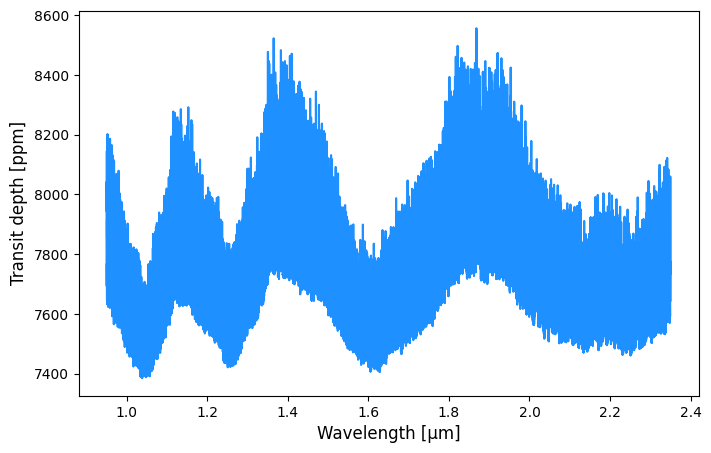

In [2]:
# BASIC INFORMATION
pl_name = "TRAPPIST-1 b"
instrument = "SPIRou_with_persi"

# Parameters of the planet (NASA Exoplanet Archive)
ap     = 0.01154*u.au        # semi-major axis of planet
R_star = 0.1192*u.R_sun      # radius of star
R_pl   = 1.116*u.R_earth     # radius of planet
M_star = 0.0898*const.M_sun  # mass of star
e      = 0                   # eccentricity
w      = 4.712389*u.rad      # argument of periapsis (equal to 270 degrees)


# NIGHTS TO CROSS-CORRELATE WITH
nightlist = [
            "2019-06-14",
            "2019-09-25",
            "2020-05-31",
            "2020-08-04",
            "2020-09-08",
            "2020-09-20",
            "2020-09-26",
            "2020-09-29",
            "2021-10-21",
            "2021-10-24",
            "2021-10-27"
               ]


# MODEL DETAILS
model_directory = "/home/mathisb/Github/HRS_models/"  # where to find the models
model_filename = "prt_model_TRAPPIST-1b_H2O_v03.npz"  # name of npz model file


# REDUCTION DETAILS
reduc_version = 'v001'
nPC_list = [0]

# Where are the reductions
reduc_in_scratch = False  # in the scratch directory (True) or in the home directory (False)


# CORRELATION DETAILS
kind_trans = 'transmission'  # emission or transmission

# Define cross-correlation axes
step_RV_inj = 2.14  # 2 times the resolution of SPIRou in km/s
corr_xlim = 150  # correlation will be done with Vrad values in [-corr_xlim, corr_xlim]

# Where to output the correlations
output_in_scratch = True  # in the scratch directory (True) or in the home directory (False)


#------------------------------------------------------------------------------------------#


# Load the model
model_file = np.load(model_directory + model_filename)
wave_mod, model_spec = model_file['wave_mod'], model_file['model_spec']

# Plot it
plt.figure(figsize=(8,5))
plt.plot(wave_mod, model_spec * 1e6, color="dodgerblue")

plt.xlabel('Wavelength [μm]', fontsize=12)
plt.ylabel('Transit depth [ppm]', fontsize=12)  # transit depth: $(\frac{R_{\rm p}}{R_{\rm \star}})^2$
plt.show()


In [4]:
# OTHER INFORMATION

# Mid-transit time (BJD) of each TRAPPIST-1 b visit (calculated from Agol et al. 2021)
mid_tr_dict = {"2019-06-14": 2458649.07123219 * u.d,
               "2019-09-25": 2458751.81121859 * u.d,
               "2020-05-31": 2459001.10675595 * u.d,
               "2020-08-04": 2459066.07480784 * u.d,
               "2020-09-08": 2459100.82490157 * u.d,
               "2020-09-20": 2459112.91190288 * u.d,
               "2020-09-26": 2459118.95517189 * u.d,
               "2020-09-29": 2459121.97749932 * u.d,
               "2021-10-21": 2459508.7625026763 * u.d,
               "2021-10-24": 2459511.7847065893 * u.d,
               "2021-10-27": 2459514.8059848337 * u.d,
                }

# Planet parameters dict
pl_kwargs = {'M_star': M_star, 
                 'R_star': R_star,
                 'ap': ap,
                 'R_pl': R_pl,
                 'excent': e,
                 'w': w}

# Reduction filenames
filename_list = [
    f"sequence_{n}-pc_mask_wings97_data_trs_{visit}.npz"
    for visit in nightlist
    for n in nPC_list
]

# Some name for files
pl_name_fname = ''.join(pl_name.split())
model_name = '_'.join(model_filename[:-4].split('_')[-3:])


# Run the correlations

In [5]:
pl_obs.log.setLevel("WARNING")  # do not print all the log information


# Correlation variables
corrRV0 = np.arange(-corr_xlim, corr_xlim, step_RV_inj)  # x axis (Vrad)
all_obs = dict()
all_ccf_map = dict()
all_logl_map = dict()


for filename in filename_list:

    visit_name = filename[:-4].split('_')[-1]
    
    # Create the planet object
    mid_tr = mid_tr_dict[visit_name]
    pl_kwargs['mid_tr'] = mid_tr

    planet_obj = Planet(pl_name, **pl_kwargs)

    
    # Directory where the reductions are
    if reduc_in_scratch:
        base_dir = Path(os.environ['SCRATCH'])
    else:
        base_dir = Path.home() / "Github"
    
    reduc_dir = base_dir / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit_name}/{reduc_version}')


    # Directory where the correlations are
    if output_in_scratch:
        output_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{visit_name}')
    else:
        output_dir = Path(f'/home/mathisb/Github/HRS_correlations/{instrument}/{pl_name_fname}/{visit_name}')

    # Create figures directory if it does not exist
    fig_dir = output_dir / "Figures"
    fig_dir.mkdir(parents=True, exist_ok=True)


    # Create the observation object
    obs = pl_obs.load_single_sequences(filename, pl_name, path=reduc_dir, load_all=False, filename_end='', plot=False, planet=planet_obj)

    # Generate Kp 
    Kp_array = np.array([obs.Kp.value])

    n_pc = int(obs.params[5])
    mask_wings = int(obs.params[1] * 100)  # in percent
    
    out_filename = f'{Path(filename).stem}_ccf_logl_seq_{model_name}'


    print(f"\033[1mCorrelation for {visit_name} with {n_pc} PC\033[0m")
    print("Reduction directory is:", reduc_dir)
    print("Correlations directory is:", output_dir)

    
    try:
        # Check if already generated
        saved_values = np.load(output_dir / Path(out_filename).with_suffix('.npz'))
        ccf_map = saved_values['corr']
        logl_map = saved_values['logl']
        print(f"Correlation already generated. Loading saved values...")
        print("-------------------------\n")
        
    except FileNotFoundError:
        # Generate 1d correlations  --  ccf_map shape: (n_exposures, n_order, n_Kp, n_vsys, n_pc, n_model) 
        ccf_map, logl_map = corr.calc_logl_injred(obs, 'seq', planet_obj, Kp_array, corrRV0, [n_pc], wave_mod, model_spec, kind_trans)
        corr.save_logl_seq(output_dir / Path(out_filename), ccf_map, logl_map, wave_mod, model_spec, n_pc, Kp_array, corrRV0, kind_trans)
    
    all_obs[(visit_name, n_pc)] = obs
    all_ccf_map[(visit_name, n_pc)] = ccf_map
    all_logl_map[(visit_name, n_pc)] = logl_map


pl_obs.log.setLevel("INFO")  # go back to normal log printing

Correlation for 2019-06-14 with 0 PC
Reduction directory is: /home/mathisb/Github/HRS_reductions/SPIRou_with_persi/TRAPPIST-1b/2019-06-14/v001
Correlations directory is: /scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/2019-06-14
Correlation already generated. Loading saved values...
-------------------------

Correlation for 2019-09-25 with 0 PC
Reduction directory is: /home/mathisb/Github/HRS_reductions/SPIRou_with_persi/TRAPPIST-1b/2019-09-25/v001
Correlations directory is: /scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/2019-09-25
Correlation already generated. Loading saved values...
-------------------------

Correlation for 2020-05-31 with 0 PC
Reduction directory is: /home/mathisb/Github/HRS_reductions/SPIRou_with_persi/TRAPPIST-1b/2020-05-31/v001
Correlations directory is: /scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/2020-05-31
Correlation already generated. Loading saved values...
-------------------------

Correlation for 202

# Plot the correlations

## Cross-correlation time series in planet rest frame

2019-06-14
Max value at 0 nPC = 3.0459318178784702 at -5.029873342053942 km/s
Max value at 0 nPC = 3.0544021788726297 at -5.028731274823194 km/s
Max value at 0 nPC = 3.0544021788726297 at -5.028731274823194 km/s


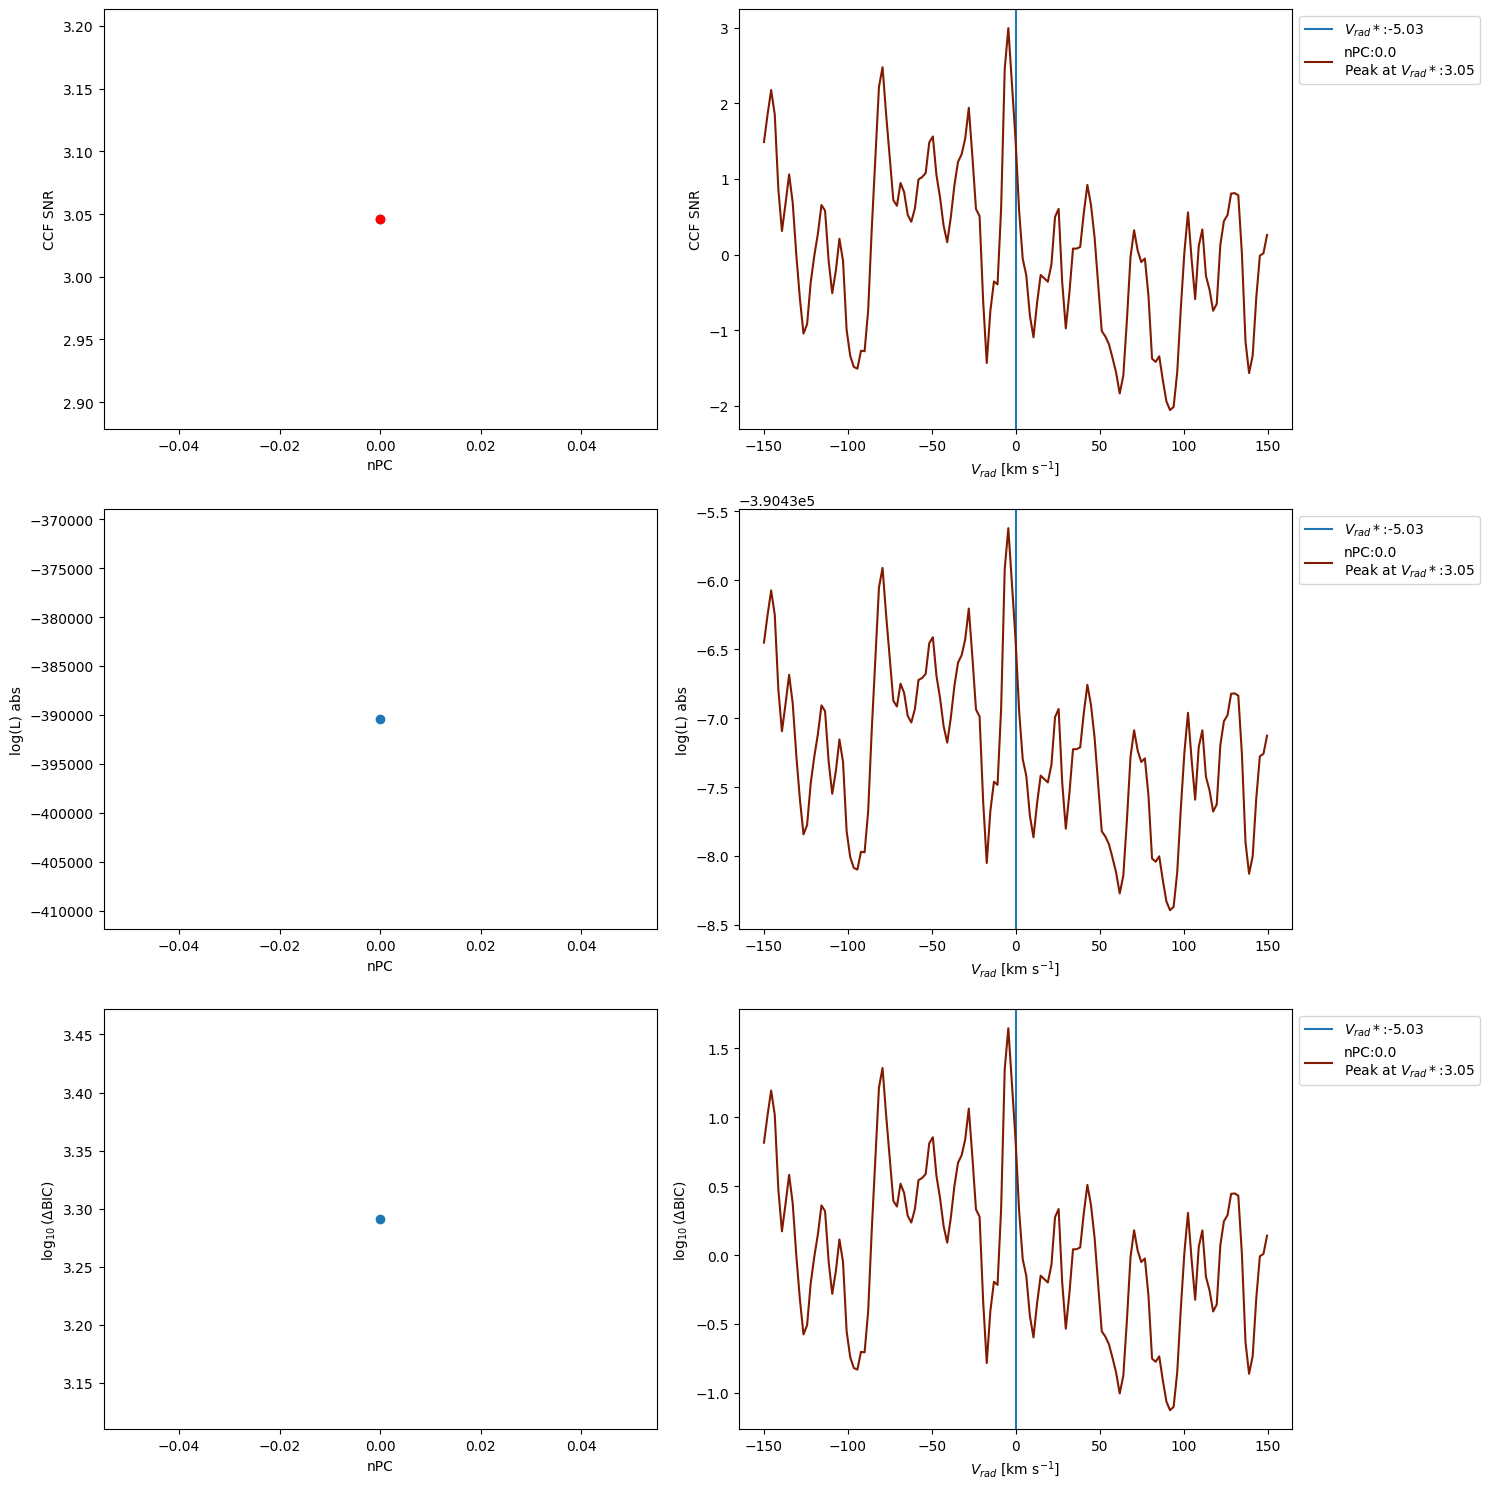

CCF SNR peak at Vrad*: [3.04593182]
log(L) abs peak at Vrad*: [-390435.62209432]
log_10(ΔBIC) peak at Vrad*: [3.29084335]
Saved file to :  /scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/2019-06-14/Figures/fig_CCF_2Dsequence_0-pc_mask_wings97_data_trs_2019-06-14_ccf_logl_seq_TRAPPIST-1b_H2O_v03_pc0.pdf
In-transit t-val = 2.47 / p-val 3.09e-02 / sig = 1.87
Out-of-transit t-val = 5.11 / p-val 1.47e-05 / sig = 4.18


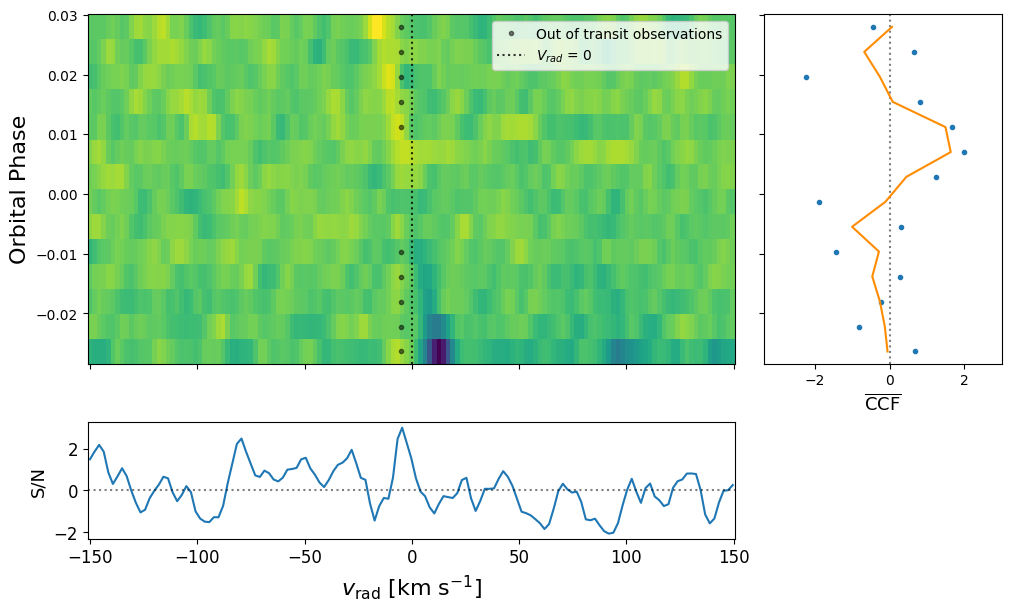



2019-09-25
Max value at 0 nPC = -1.5416764214512353 at -6.6199965301465955 km/s
Max value at 0 nPC = -1.546866567418815 at -6.6199965301465955 km/s
Max value at 0 nPC = -1.546866567418815 at -6.6199965301465955 km/s


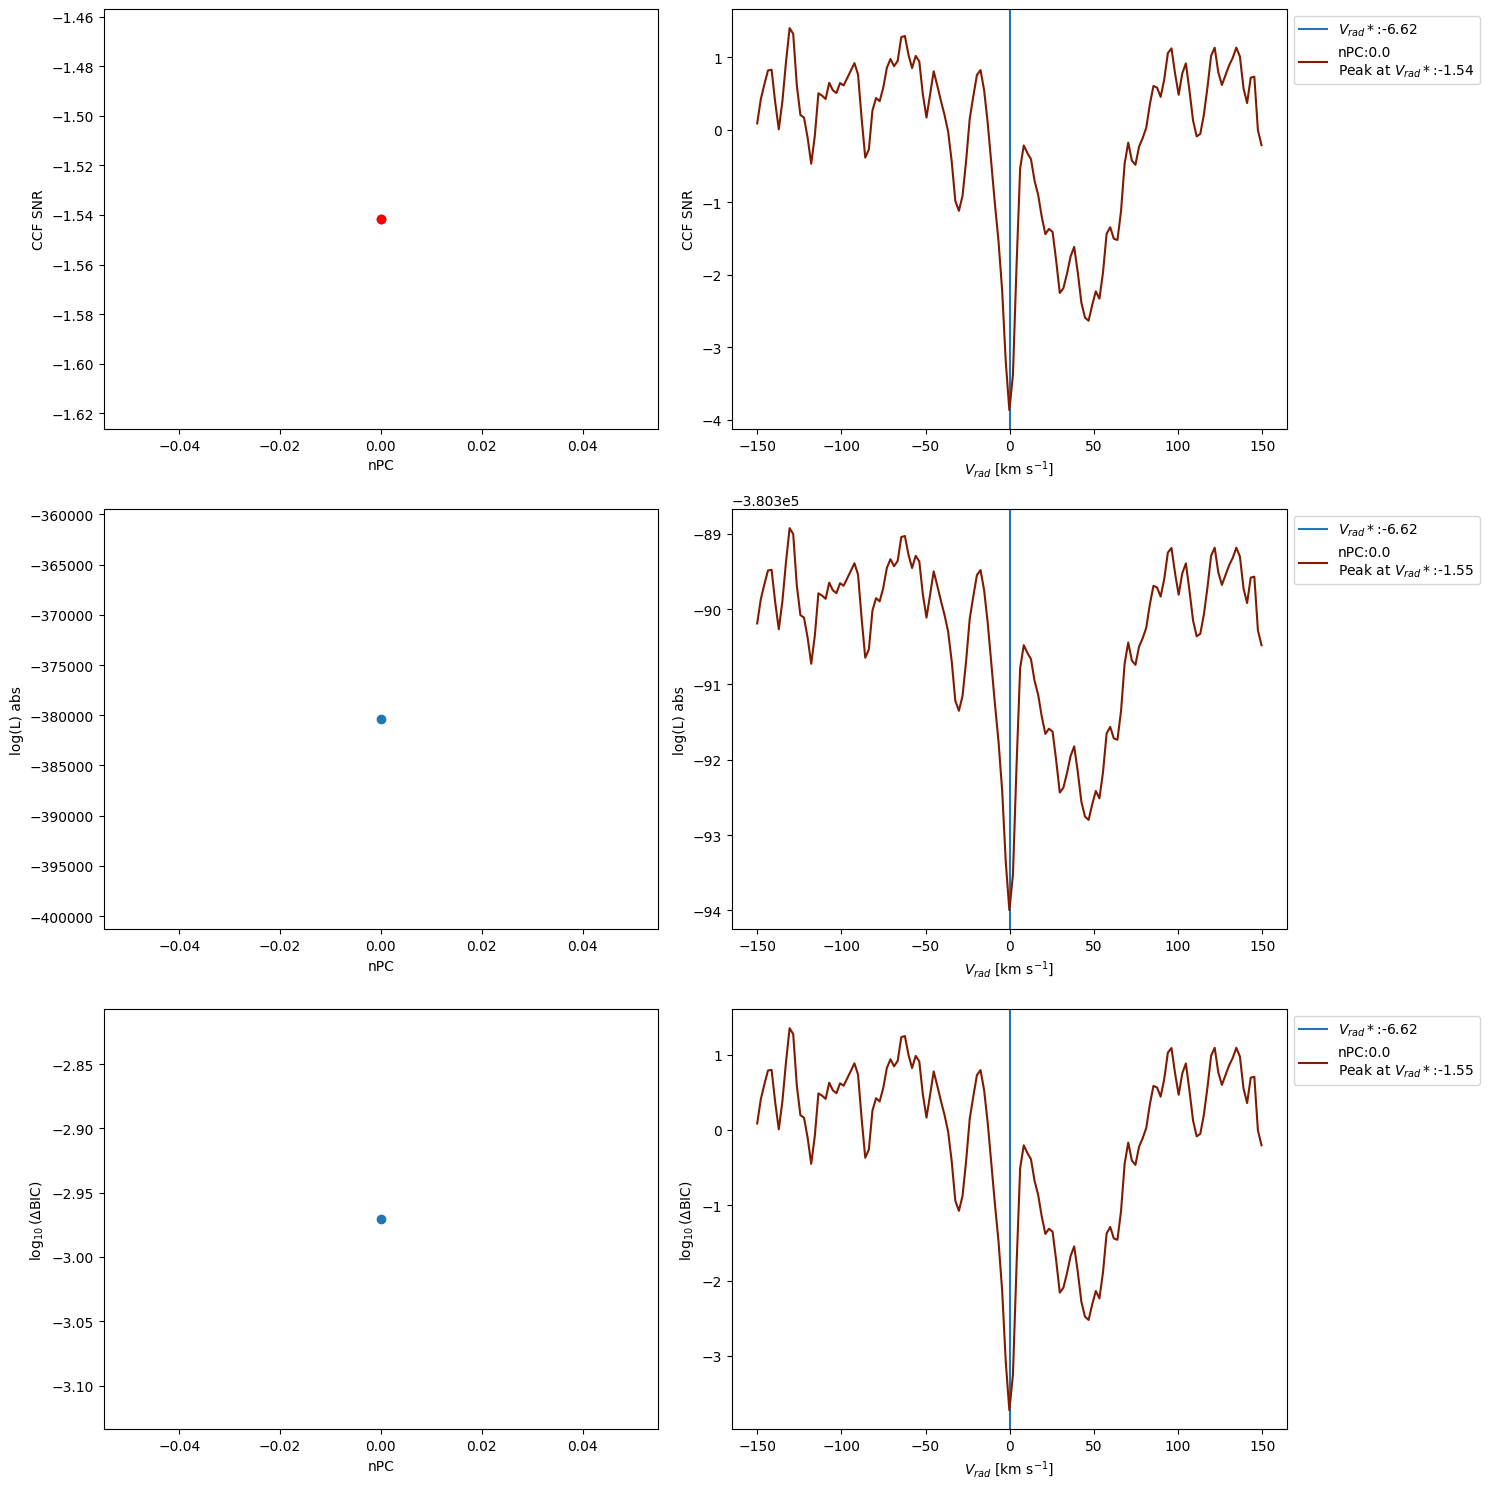

CCF SNR peak at Vrad*: [-1.54167642]
log(L) abs peak at Vrad*: [-380391.76095546]
log_10(ΔBIC) peak at Vrad*: [-2.97065056]
Saved file to :  /scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/2019-09-25/Figures/fig_CCF_2Dsequence_0-pc_mask_wings97_data_trs_2019-09-25_ccf_logl_seq_TRAPPIST-1b_H2O_v03_pc0.pdf
In-transit t-val = -2.93 / p-val 1.33e-02 / sig = 2.22
Out-of-transit t-val = -1.16 / p-val 2.55e-01 / sig = 0.66


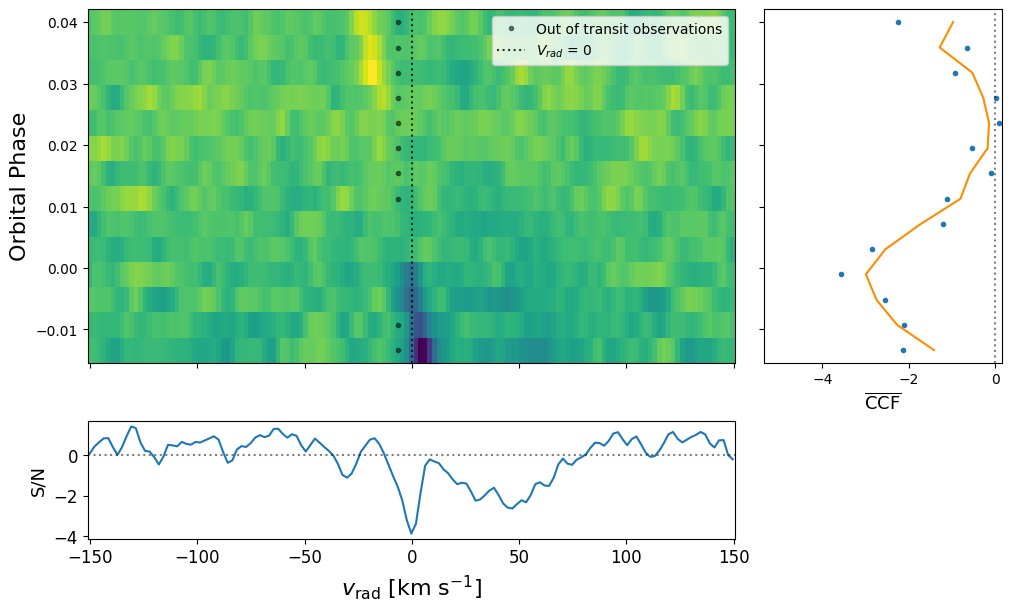



2020-05-31
Max value at 0 nPC = 2.8411233172200805 at -1.623850902948646 km/s
Max value at 0 nPC = 2.85246549573738 at -1.6267802127727737 km/s
Max value at 0 nPC = 2.85246549573738 at -1.6267802127727737 km/s


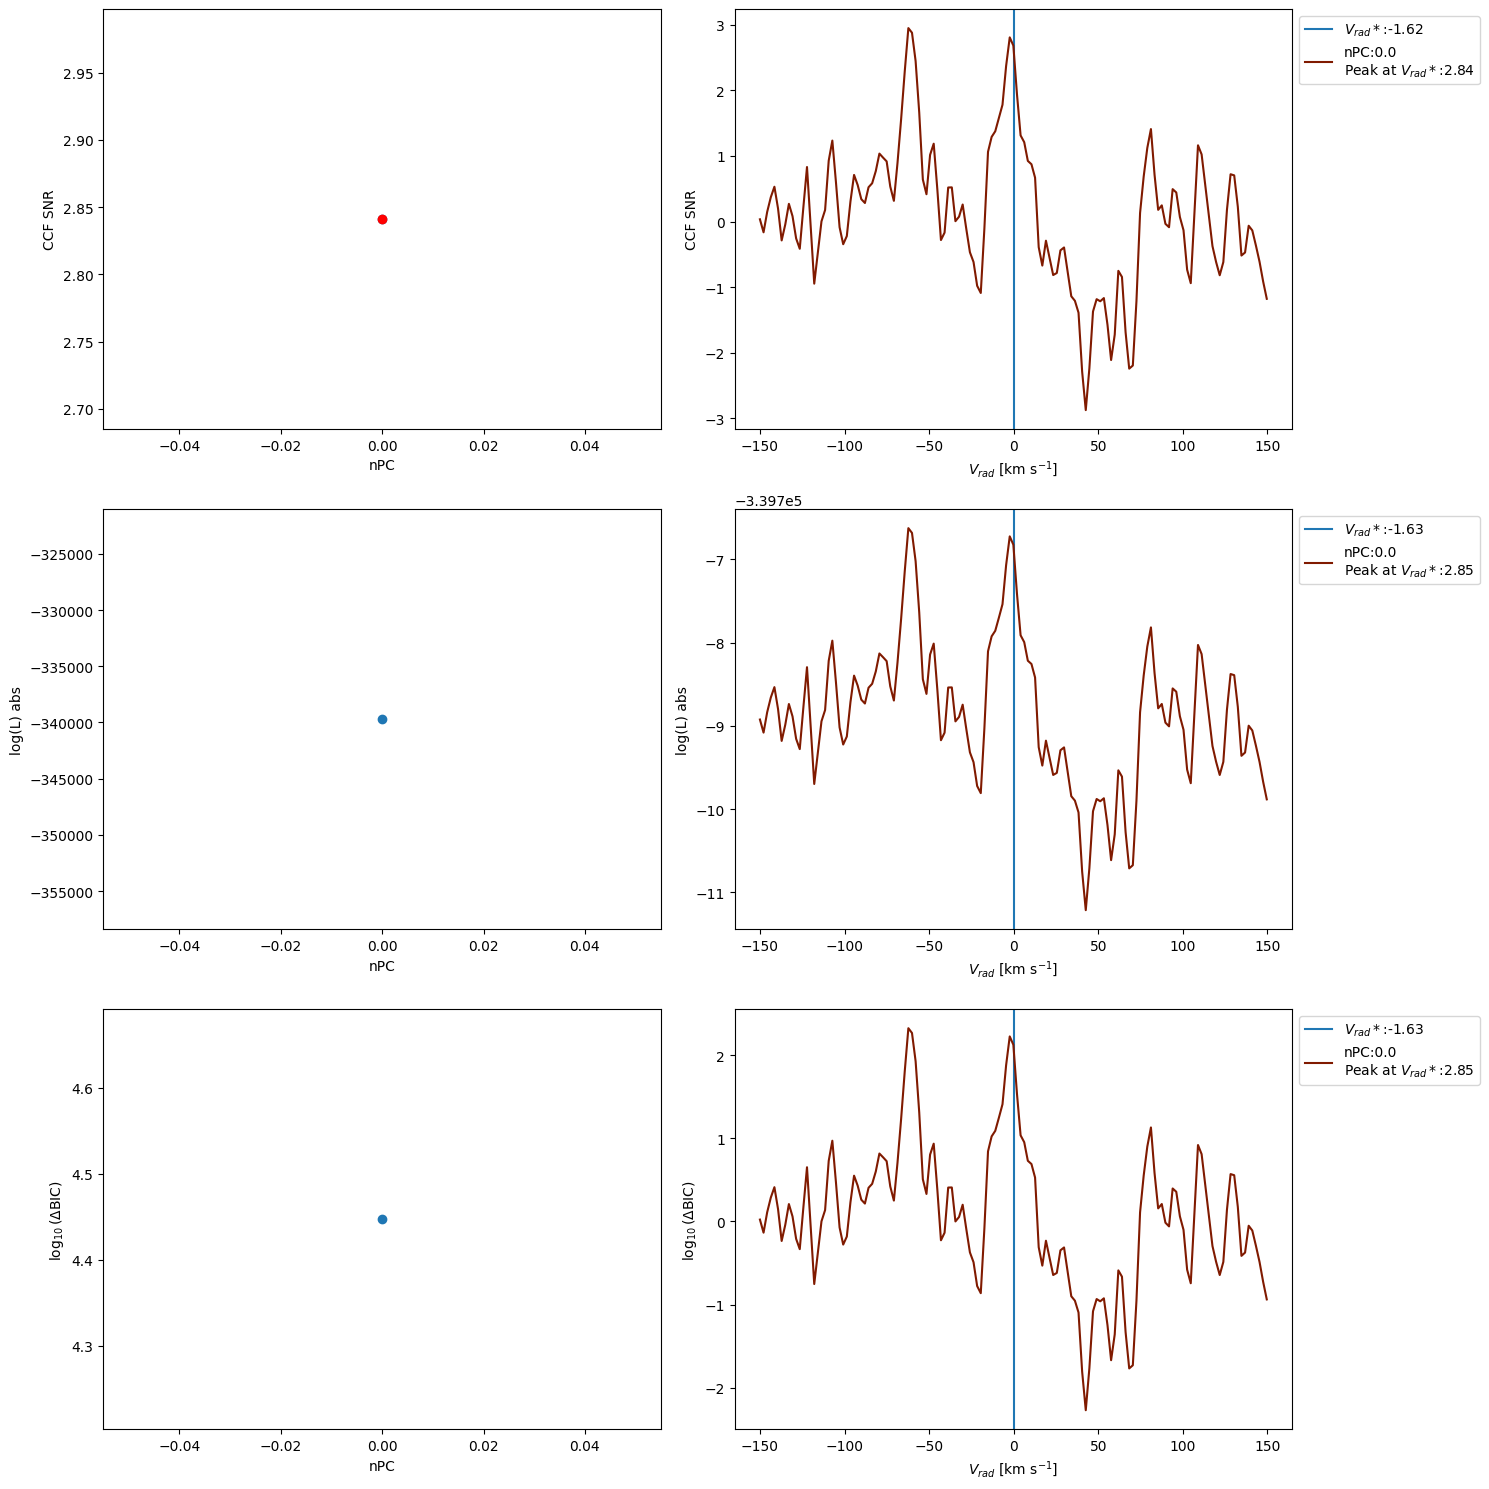

CCF SNR peak at Vrad*: [2.84112332]
log(L) abs peak at Vrad*: [-339706.72325133]
log_10(ΔBIC) peak at Vrad*: [4.4470085]
Saved file to :  /scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/2020-05-31/Figures/fig_CCF_2Dsequence_0-pc_mask_wings97_data_trs_2020-05-31_ccf_logl_seq_TRAPPIST-1b_H2O_v03_pc0.pdf
In-transit t-val = 8.76 / p-val 1.57e-06 / sig = 4.66
Out-of-transit t-val = -0.70 / p-val 4.87e-01 / sig = 0.03


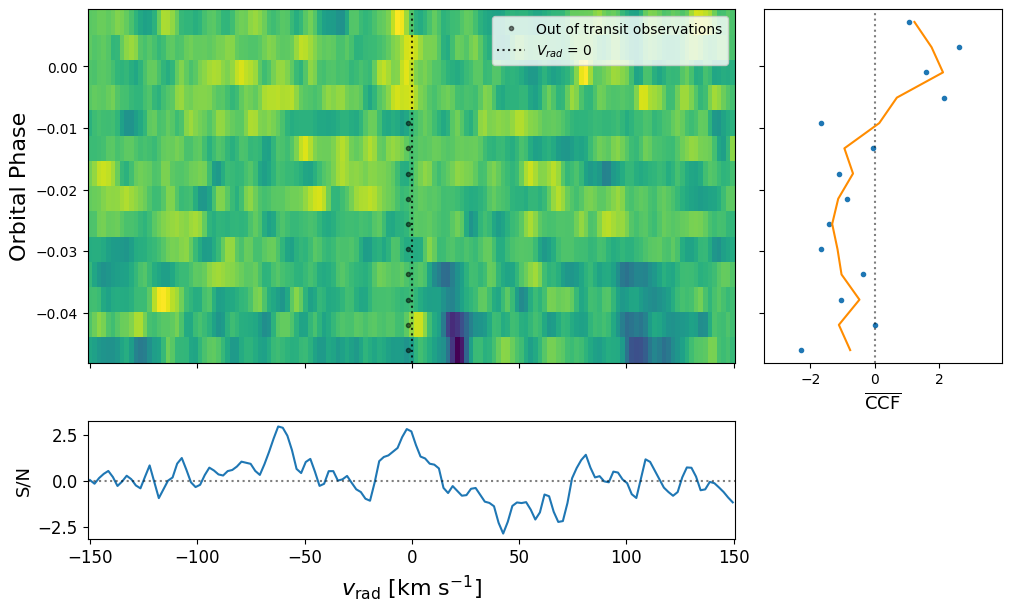



2020-08-04
Max value at 0 nPC = 0.9221718685486173 at 4.314221352132133 km/s
Max value at 0 nPC = 0.927139557552338 at 4.29905430277581 km/s
Max value at 0 nPC = 0.927139557552338 at 4.29905430277581 km/s


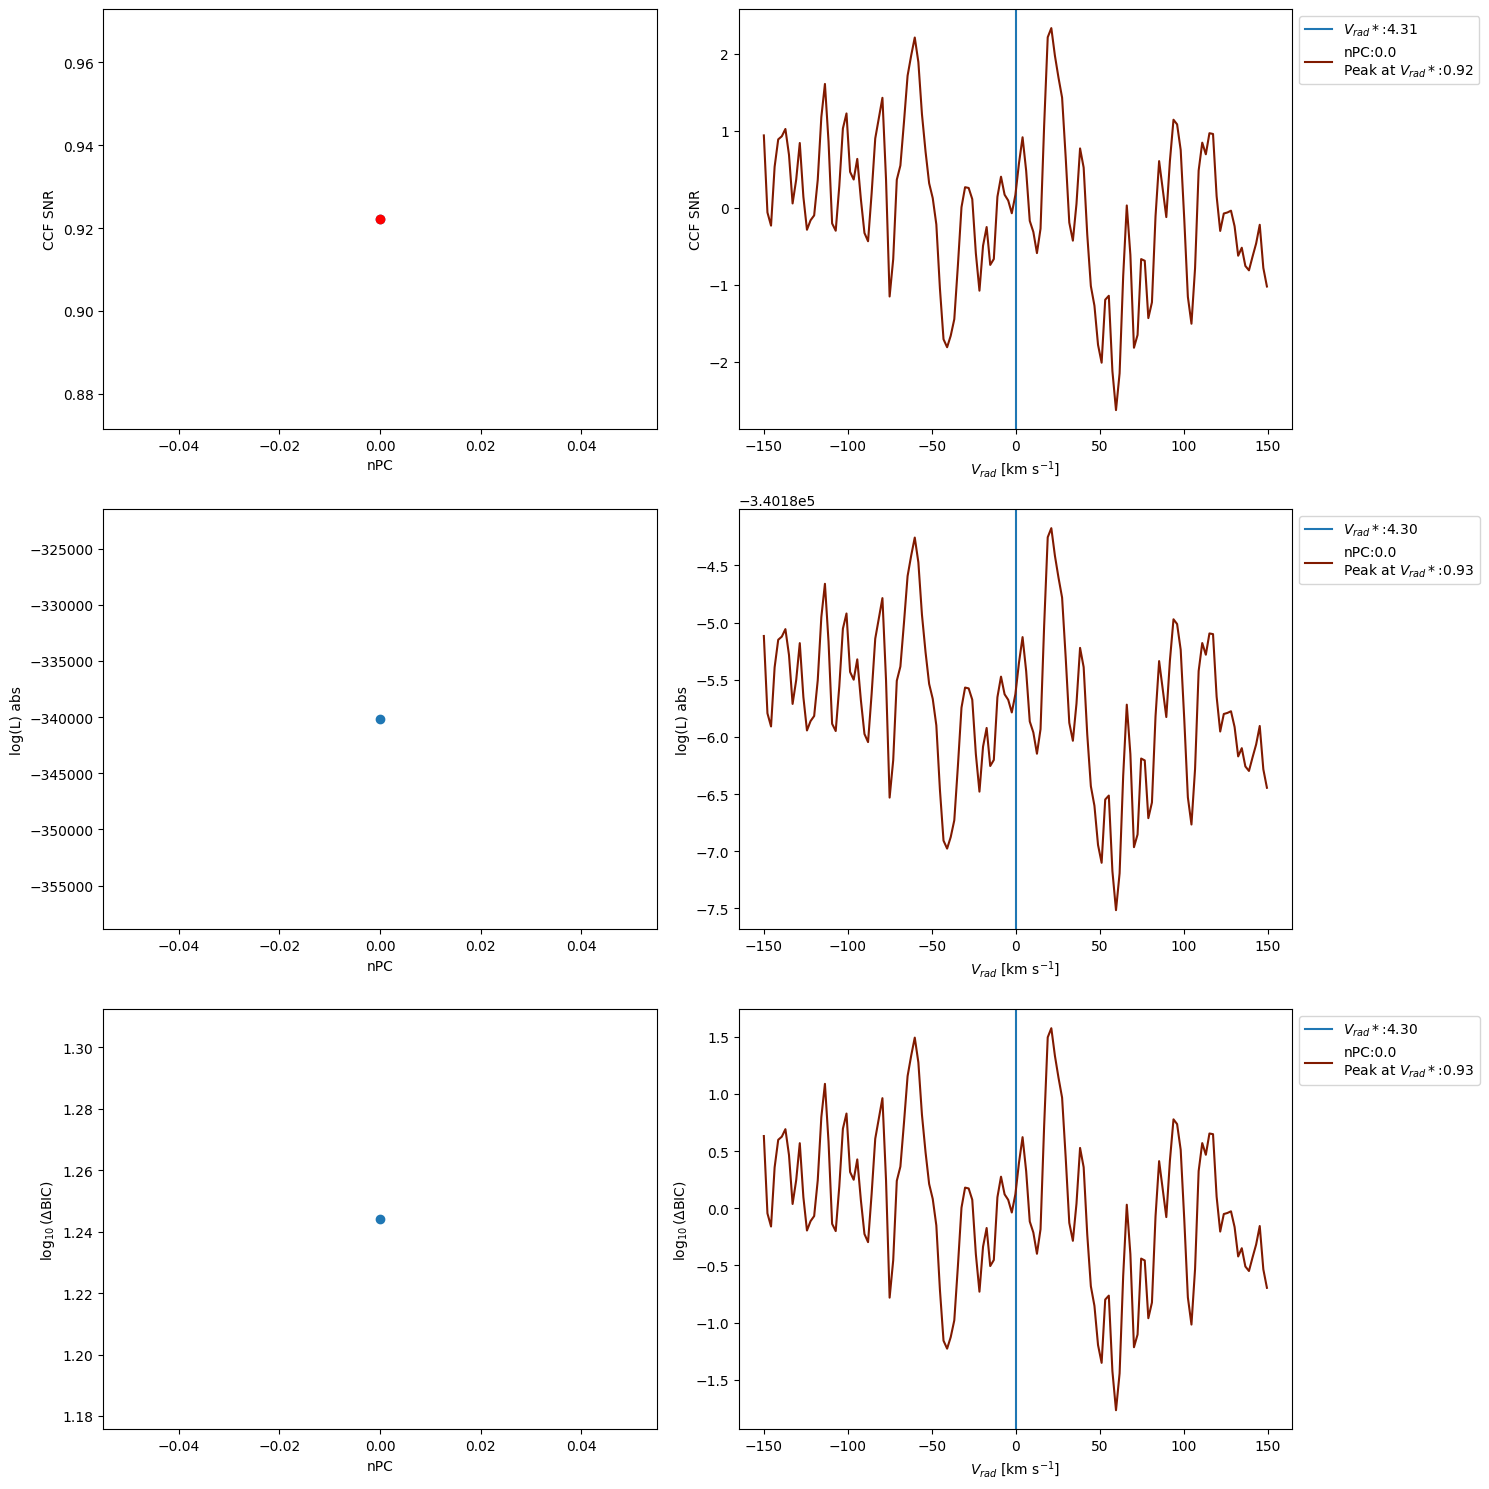

CCF SNR peak at Vrad*: [0.92217187]
log(L) abs peak at Vrad*: [-340185.12718333]
log_10(ΔBIC) peak at Vrad*: [1.2440627]
Saved file to :  /scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/2020-08-04/Figures/fig_CCF_2Dsequence_0-pc_mask_wings97_data_trs_2020-08-04_ccf_logl_seq_TRAPPIST-1b_H2O_v03_pc0.pdf
In-transit t-val = 3.43 / p-val 4.67e-03 / sig = 2.60
Out-of-transit t-val = -2.76 / p-val 8.90e-03 / sig = 2.37


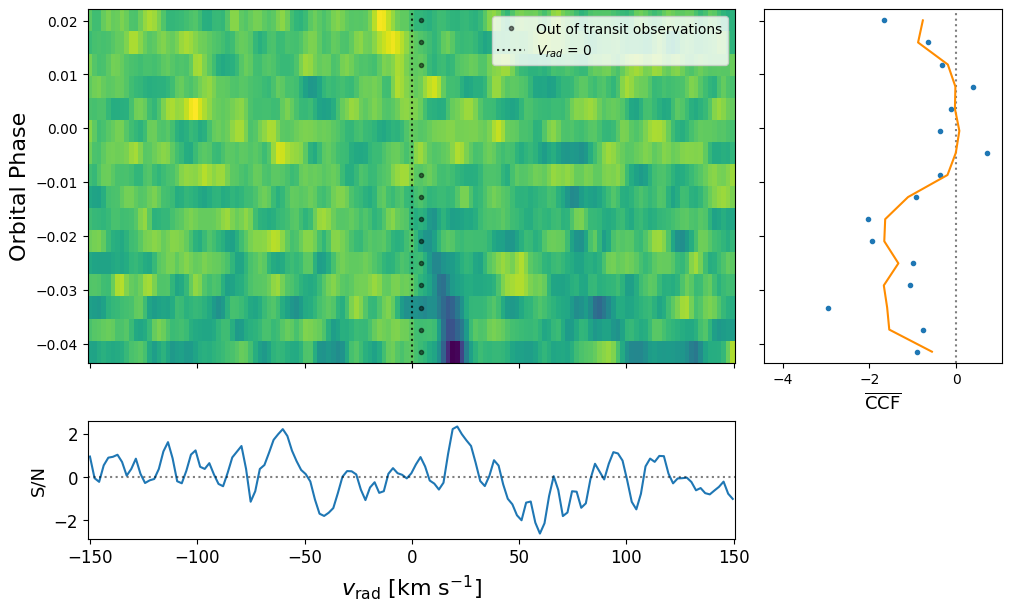



2020-09-08
Max value at 0 nPC = 0.4548826872223631 at -6.619996521023992 km/s
Max value at 0 nPC = 0.4605341858315907 at -6.619996411865014 km/s
Max value at 0 nPC = 0.4605341858315907 at -6.619996411865014 km/s


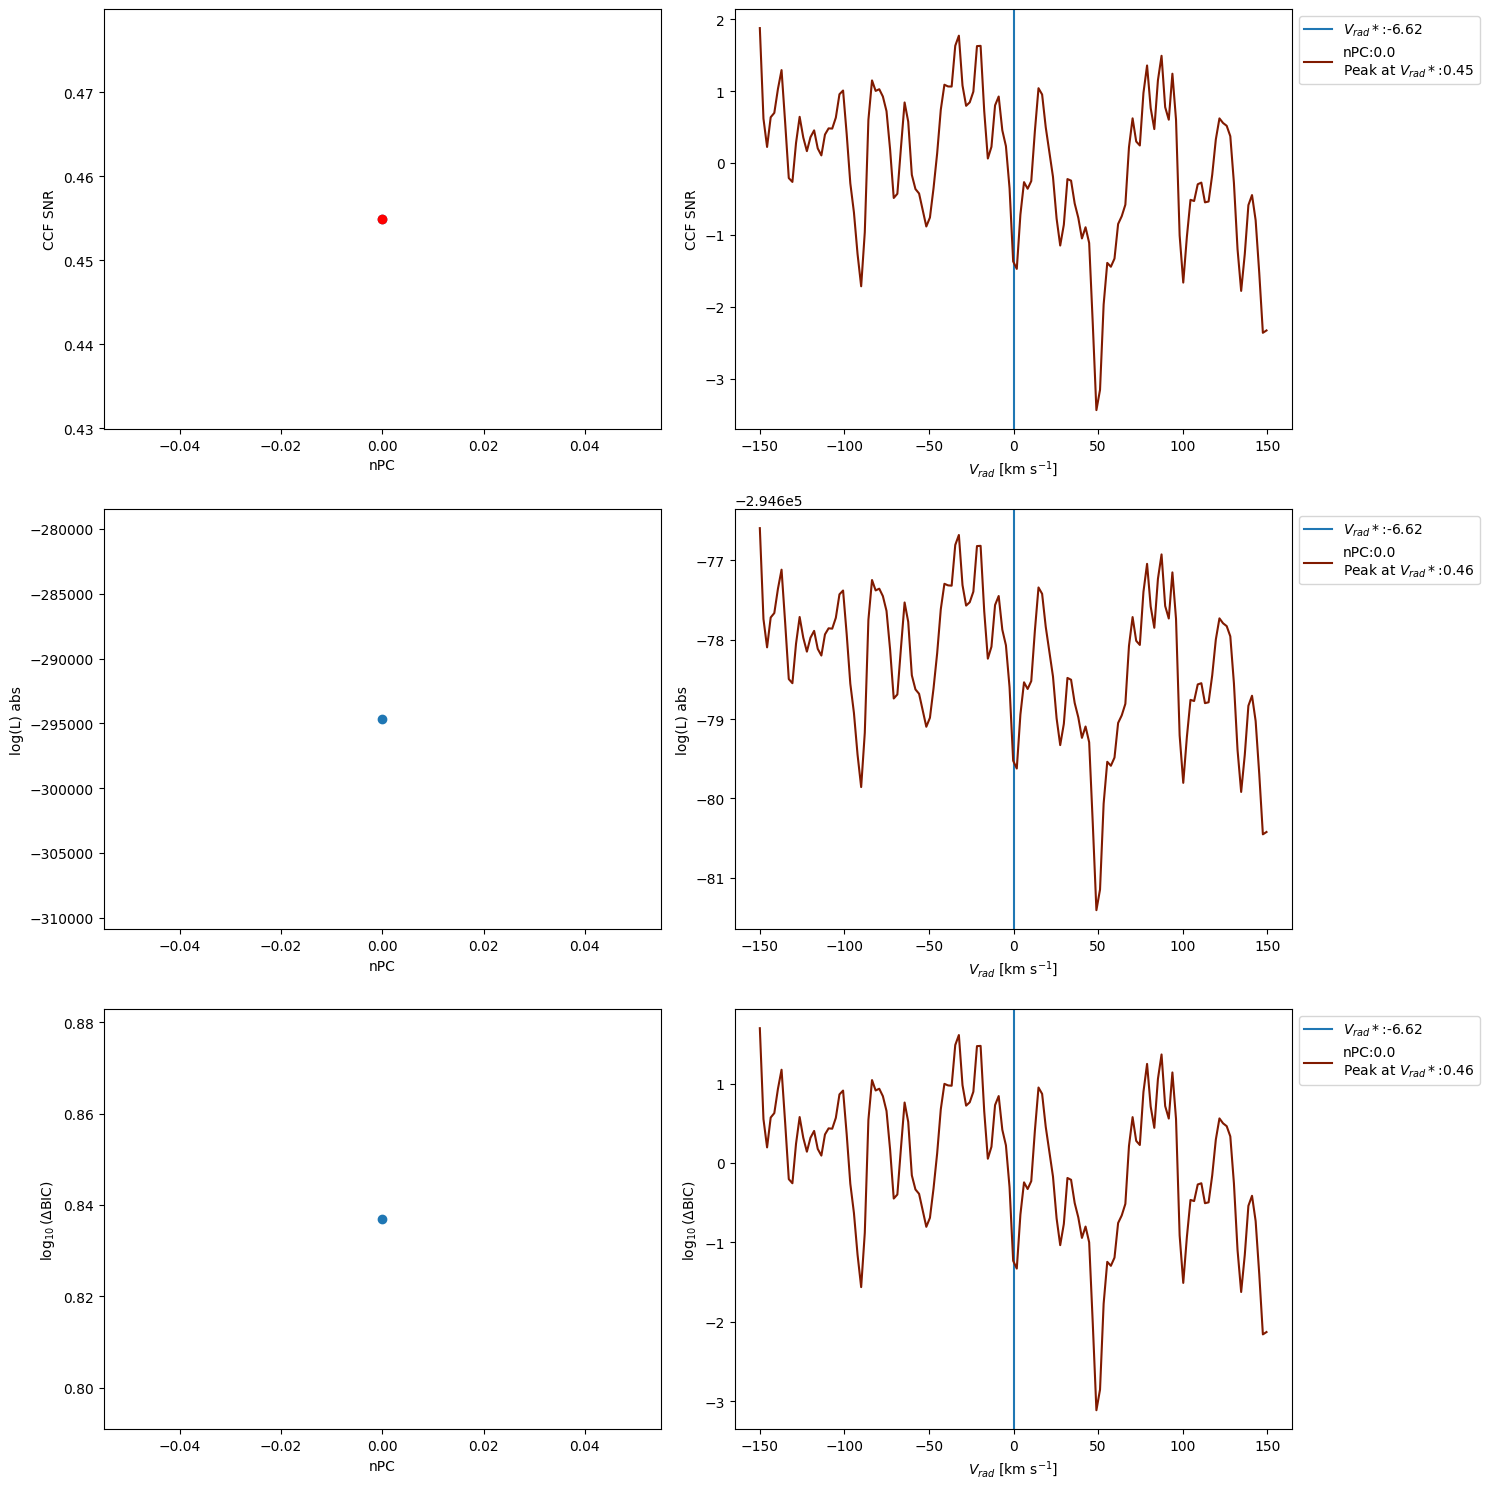

CCF SNR peak at Vrad*: [0.45488269]
log(L) abs peak at Vrad*: [-294677.87354603]
log_10(ΔBIC) peak at Vrad*: [0.83687338]
Saved file to :  /scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/2020-09-08/Figures/fig_CCF_2Dsequence_0-pc_mask_wings97_data_trs_2020-09-08_ccf_logl_seq_TRAPPIST-1b_H2O_v03_pc0.pdf
In-transit t-val = 0.29 / p-val 7.74e-01 / sig = -0.75
Out-of-transit t-val = 3.39 / p-val 1.62e-03 / sig = 2.94


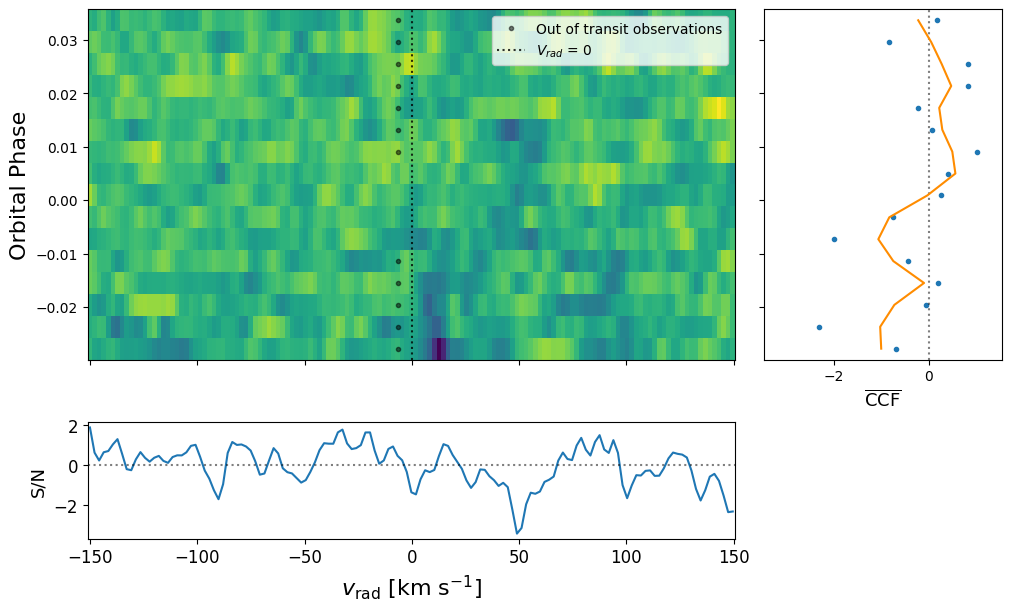



2020-09-20
Max value at 0 nPC = -0.1476590412535377 at 1.4847277908428465 km/s
Max value at 0 nPC = -0.13641965718730373 at 1.4760868140944885 km/s
Max value at 0 nPC = -0.13641965718730373 at 1.4760868140944885 km/s


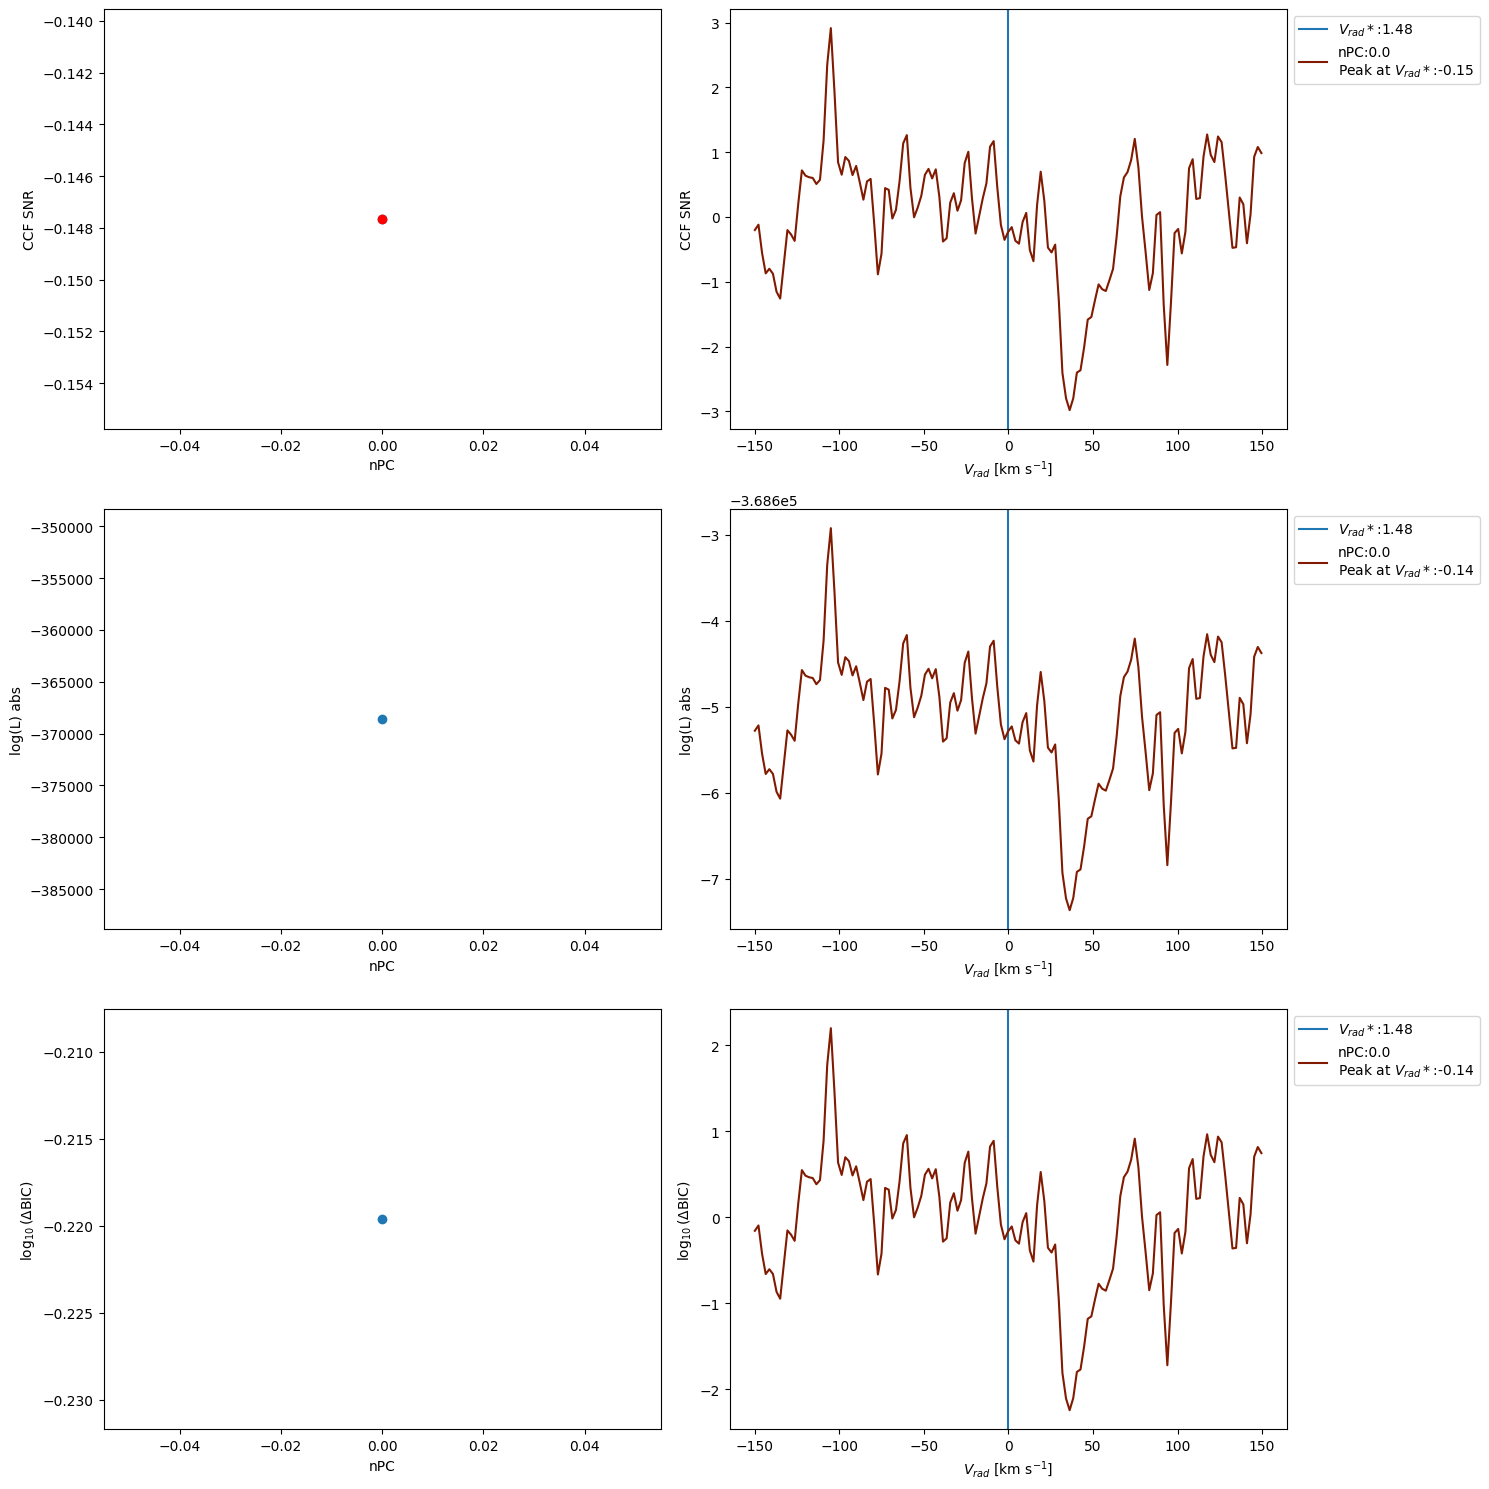

CCF SNR peak at Vrad*: [-0.14765904]
log(L) abs peak at Vrad*: [-368605.22875019]
log_10(ΔBIC) peak at Vrad*: [-0.21961949]
Saved file to :  /scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/2020-09-20/Figures/fig_CCF_2Dsequence_0-pc_mask_wings97_data_trs_2020-09-20_ccf_logl_seq_TRAPPIST-1b_H2O_v03_pc0.pdf
In-transit t-val = -1.45 / p-val 1.89e-01 / sig = 0.88
Out-of-transit t-val = -0.94 / p-val 3.57e-01 / sig = 0.37


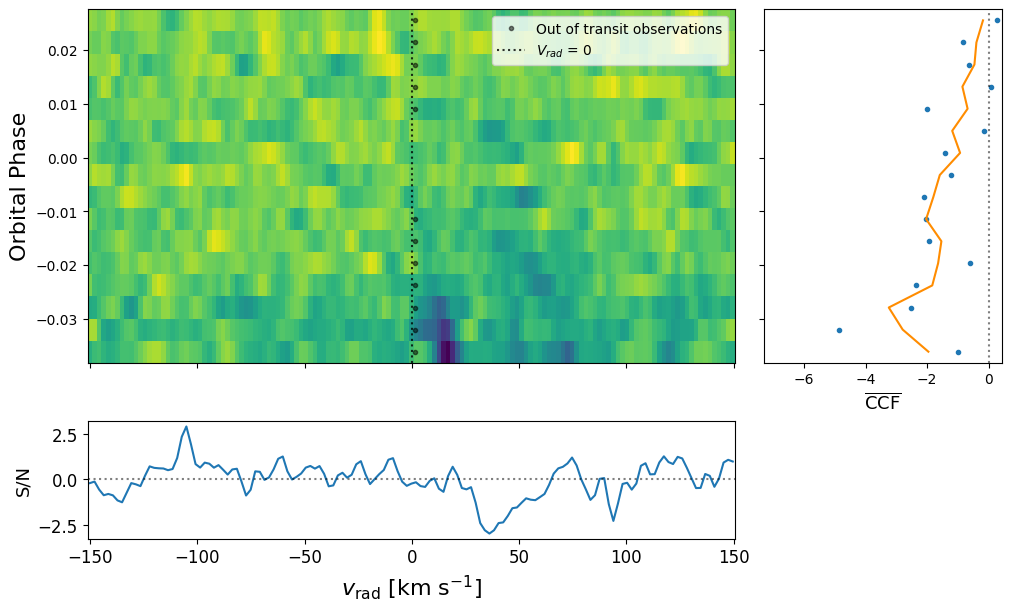



2020-09-26
Max value at 0 nPC = 1.9819719701169984 at -2.215684795924014 km/s
Max value at 0 nPC = 2.0020328065784865 at -2.2197520649955846 km/s
Max value at 0 nPC = 2.0020328065784865 at -2.2197520649955846 km/s


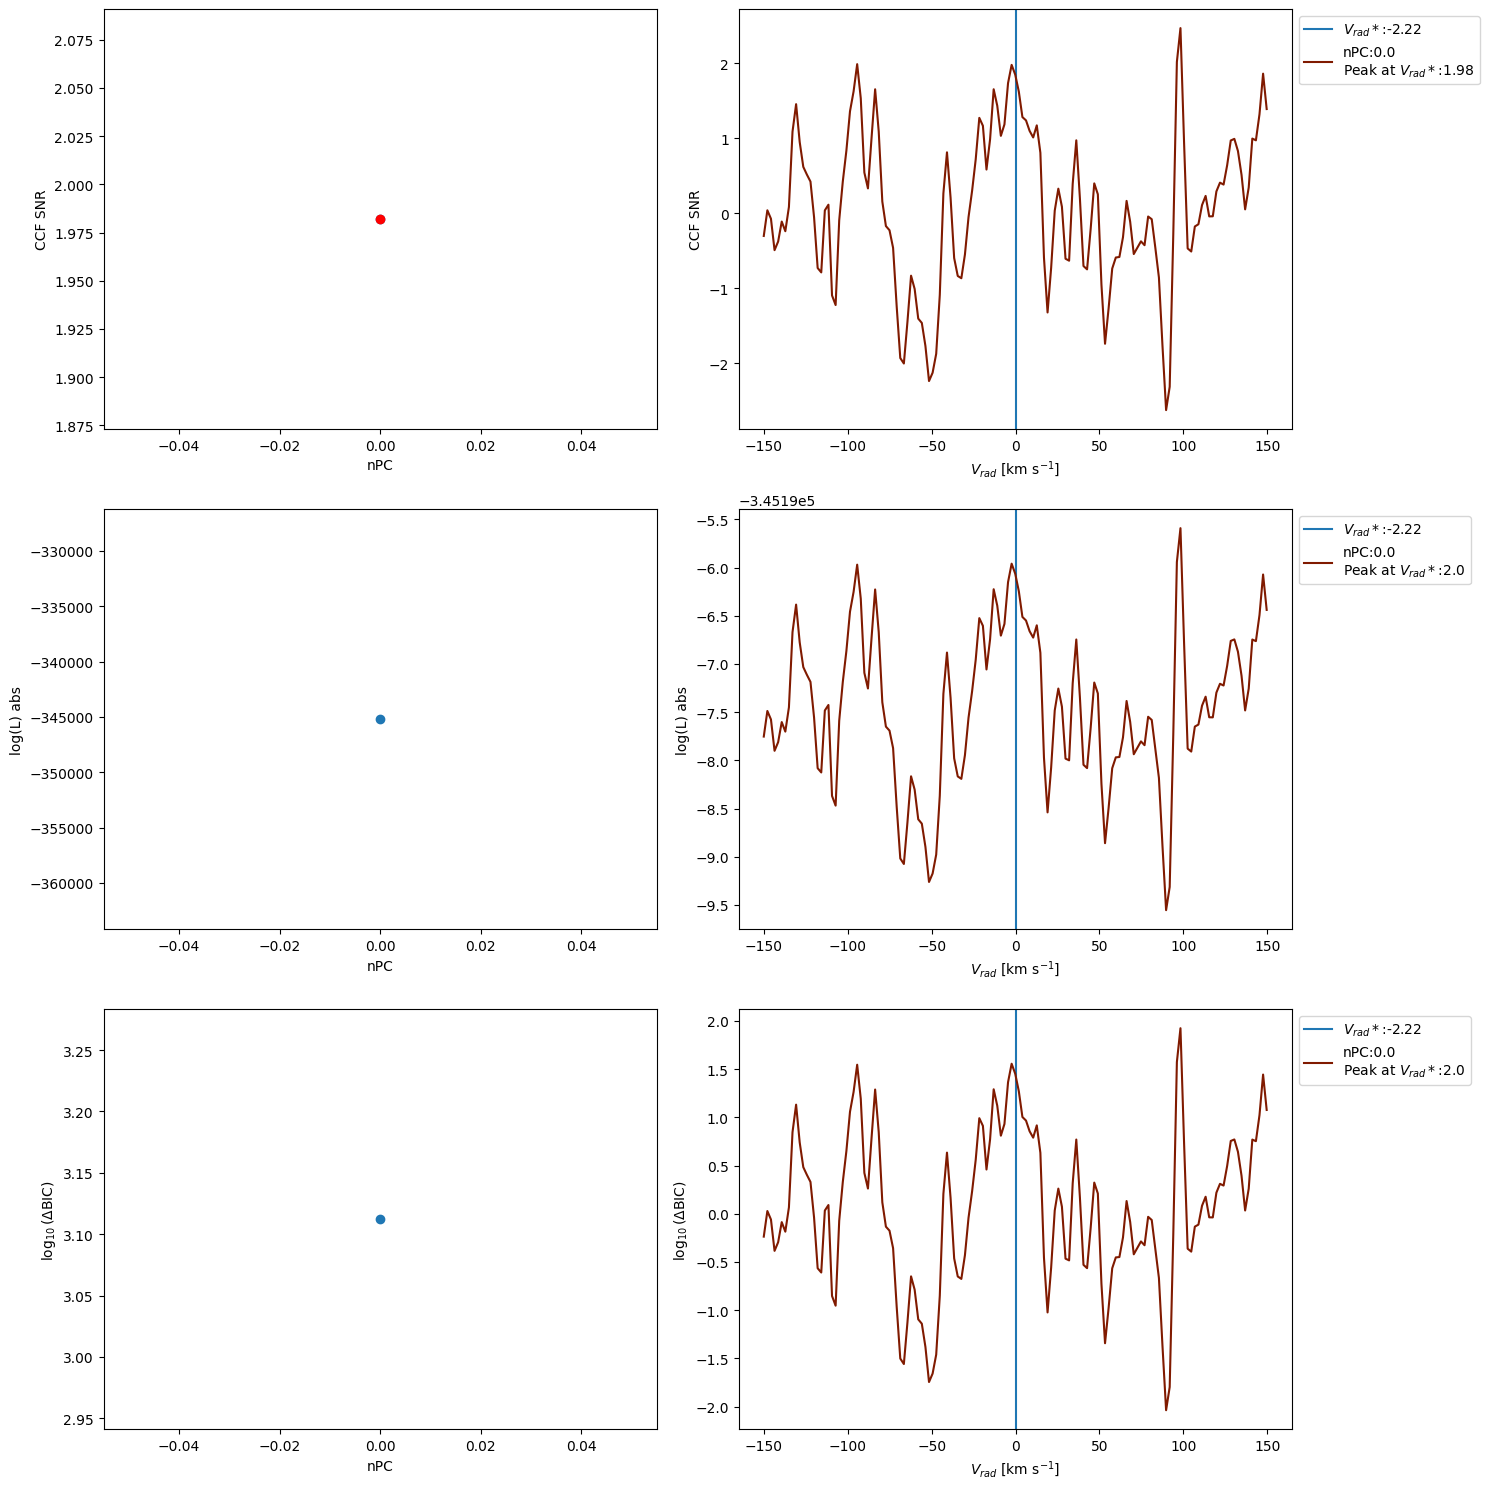

CCF SNR peak at Vrad*: [1.98197197]
log(L) abs peak at Vrad*: [-345195.95962025]
log_10(ΔBIC) peak at Vrad*: [3.11216998]
Saved file to :  /scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/2020-09-26/Figures/fig_CCF_2Dsequence_0-pc_mask_wings97_data_trs_2020-09-26_ccf_logl_seq_TRAPPIST-1b_H2O_v03_pc0.pdf
In-transit t-val = 4.31 / p-val 1.10e-03 / sig = 3.06
Out-of-transit t-val = 3.18 / p-val 2.94e-03 / sig = 2.75


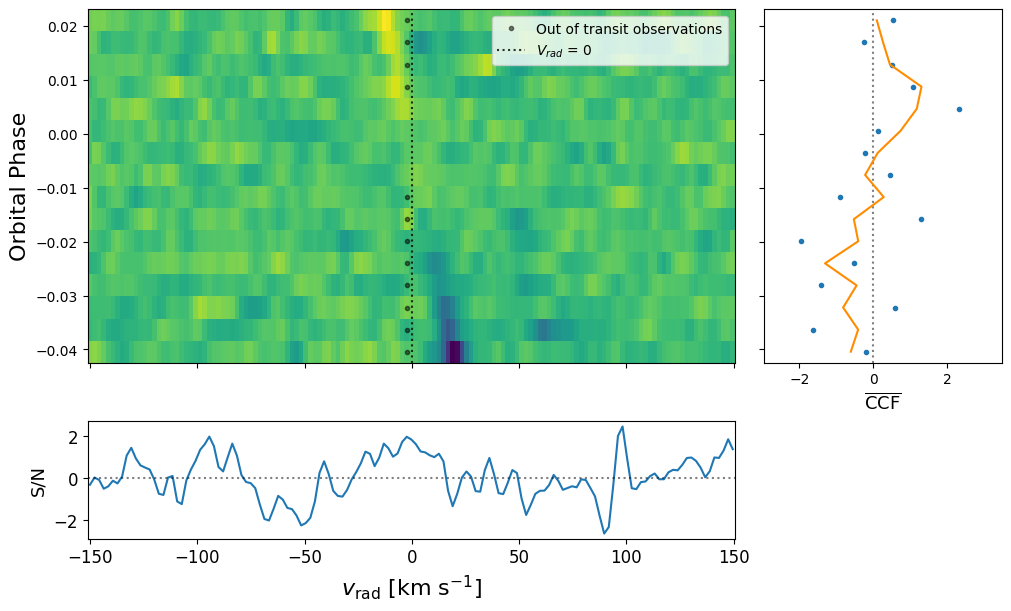



2020-09-29
Max value at 0 nPC = 0.8919738908193384 at -3.0929754696698315 km/s
Max value at 0 nPC = 0.9000045548570302 at -3.0826969721219384 km/s
Max value at 0 nPC = 0.9000045548570302 at -3.0826969721219384 km/s


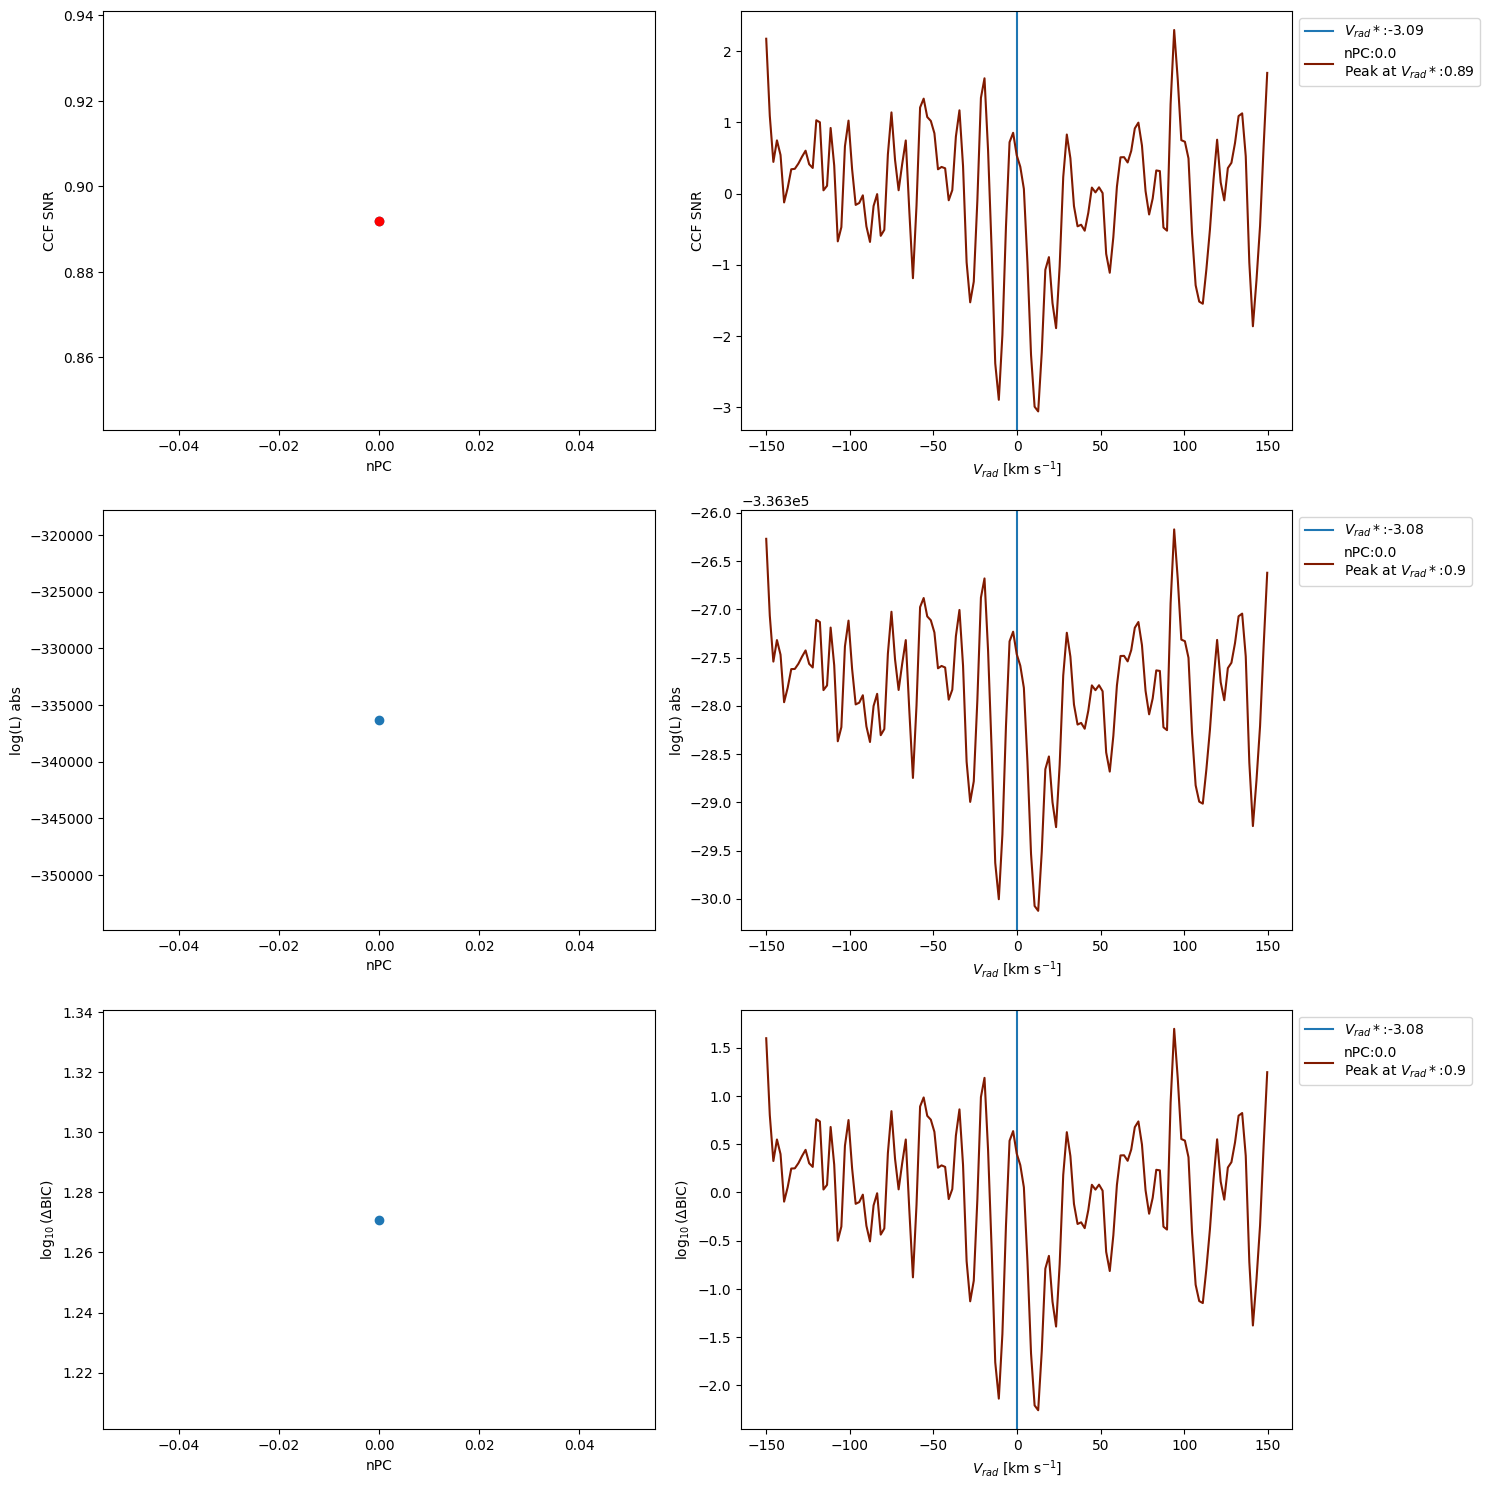

CCF SNR peak at Vrad*: [0.89197389]
log(L) abs peak at Vrad*: [-336327.23221853]
log_10(ΔBIC) peak at Vrad*: [1.27097815]
Saved file to :  /scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/2020-09-29/Figures/fig_CCF_2Dsequence_0-pc_mask_wings97_data_trs_2020-09-29_ccf_logl_seq_TRAPPIST-1b_H2O_v03_pc0.pdf
In-transit t-val = 2.14 / p-val 6.69e-02 / sig = 1.50
Out-of-transit t-val = 1.57 / p-val 1.30e-01 / sig = 1.12


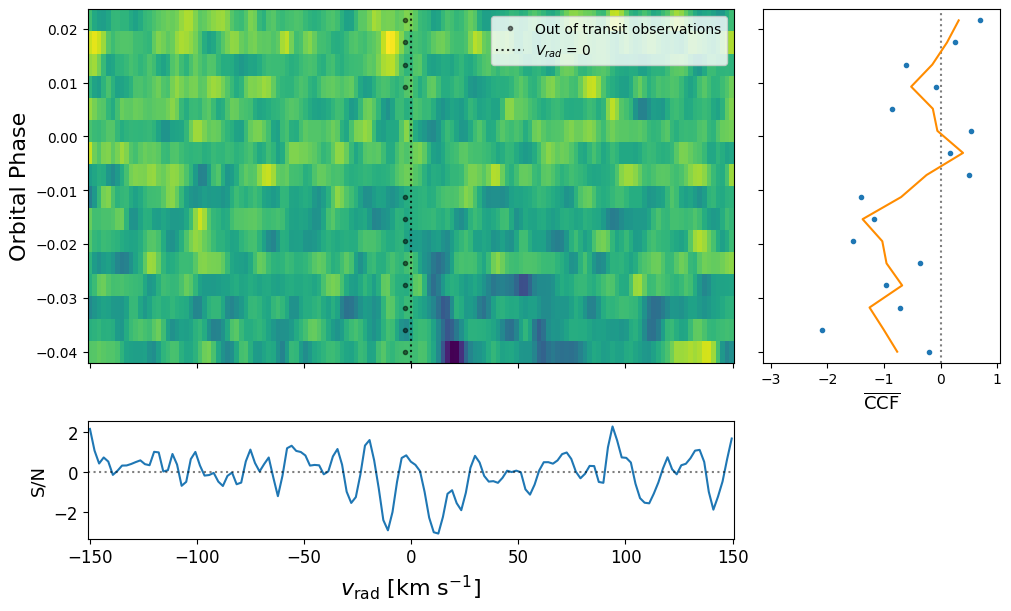



2021-10-21
Max value at 0 nPC = 2.2706208488635244 at -3.106940869299578 km/s
Max value at 0 nPC = 2.2844838374188665 at -3.1027805217848985 km/s
Max value at 0 nPC = 2.2844838374188665 at -3.1027805217848985 km/s


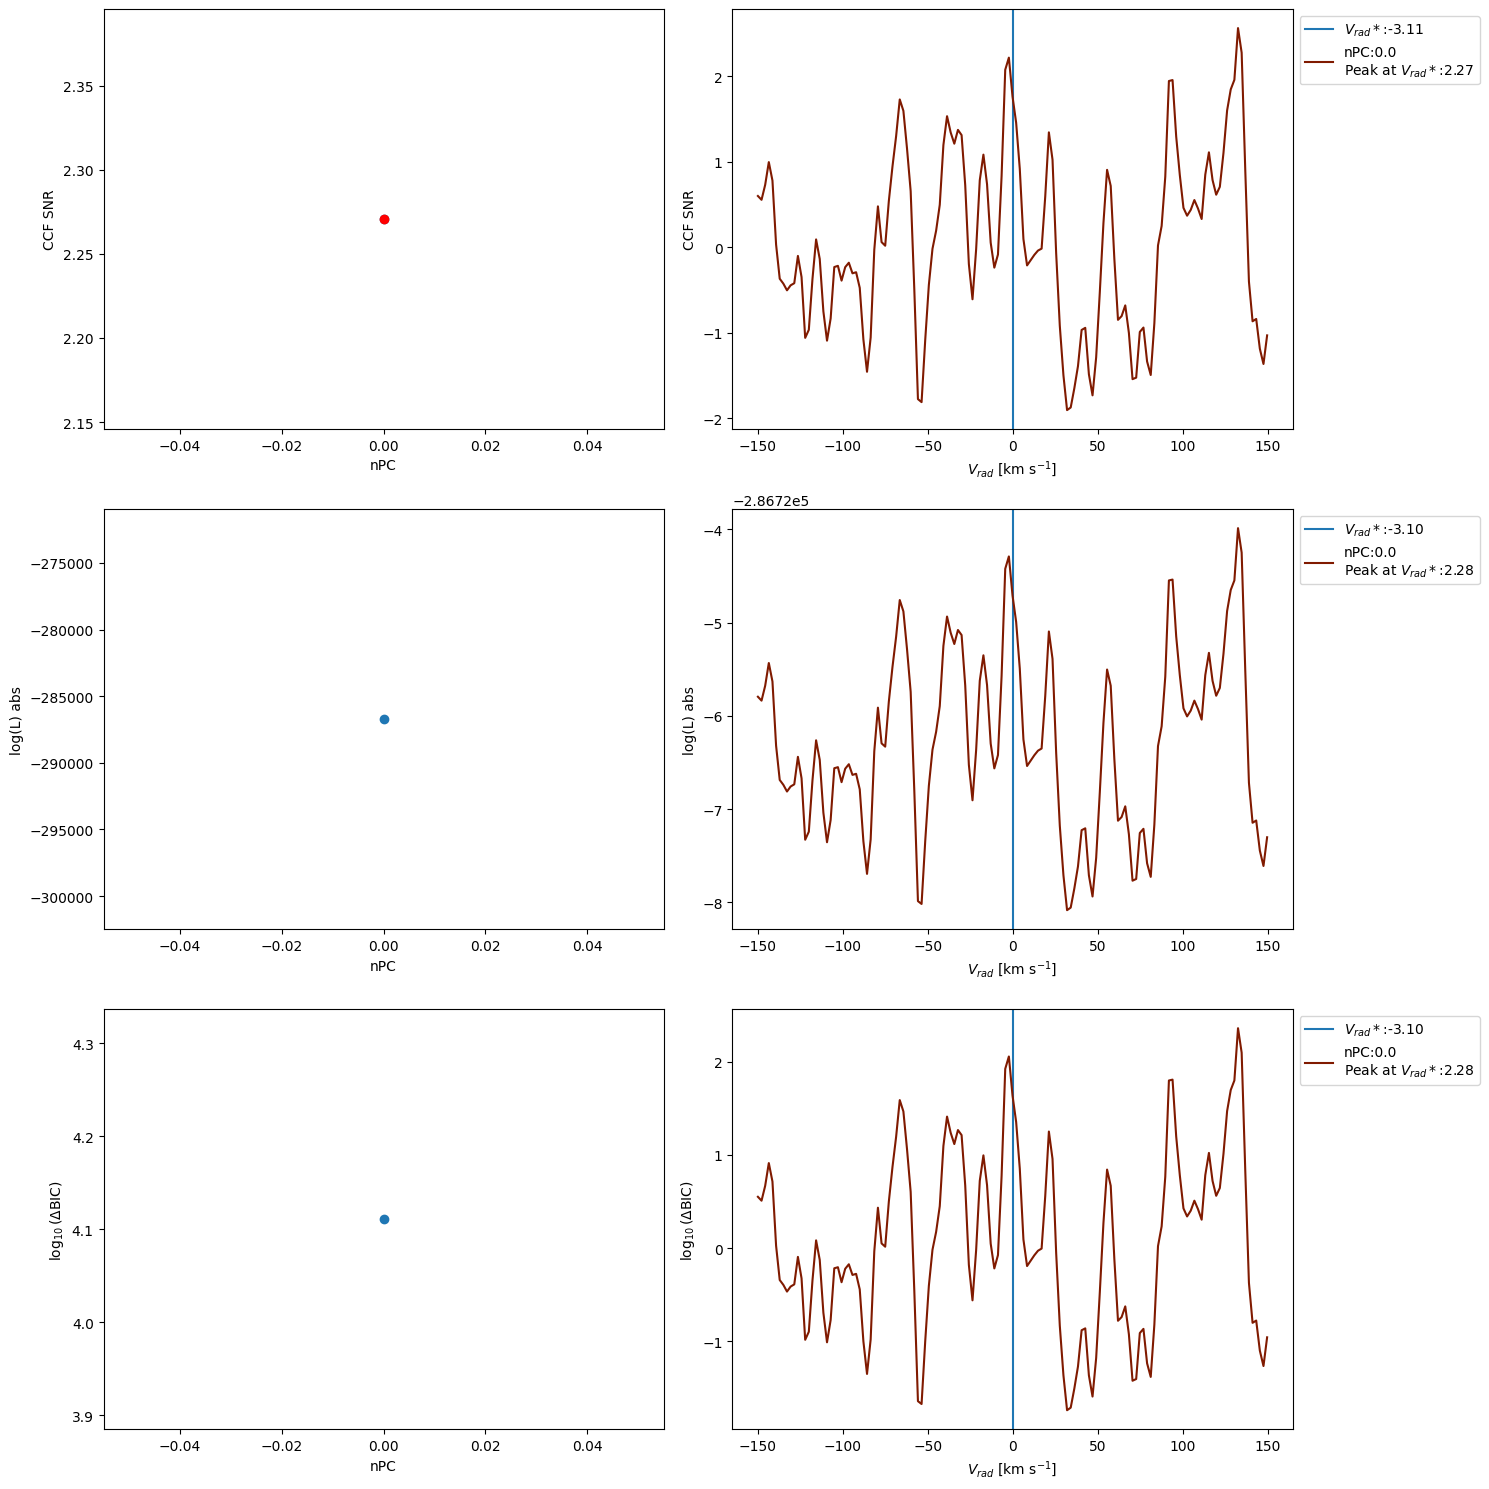

CCF SNR peak at Vrad*: [2.27062085]
log(L) abs peak at Vrad*: [-286724.28883473]
log_10(ΔBIC) peak at Vrad*: [4.11076755]
Saved file to :  /scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/2021-10-21/Figures/fig_CCF_2Dsequence_0-pc_mask_wings97_data_trs_2021-10-21_ccf_logl_seq_TRAPPIST-1b_H2O_v03_pc0.pdf
In-transit t-val = 4.71 / p-val 1.68e-03 / sig = 2.93
Out-of-transit t-val = 2.29 / p-val 3.07e-02 / sig = 1.87


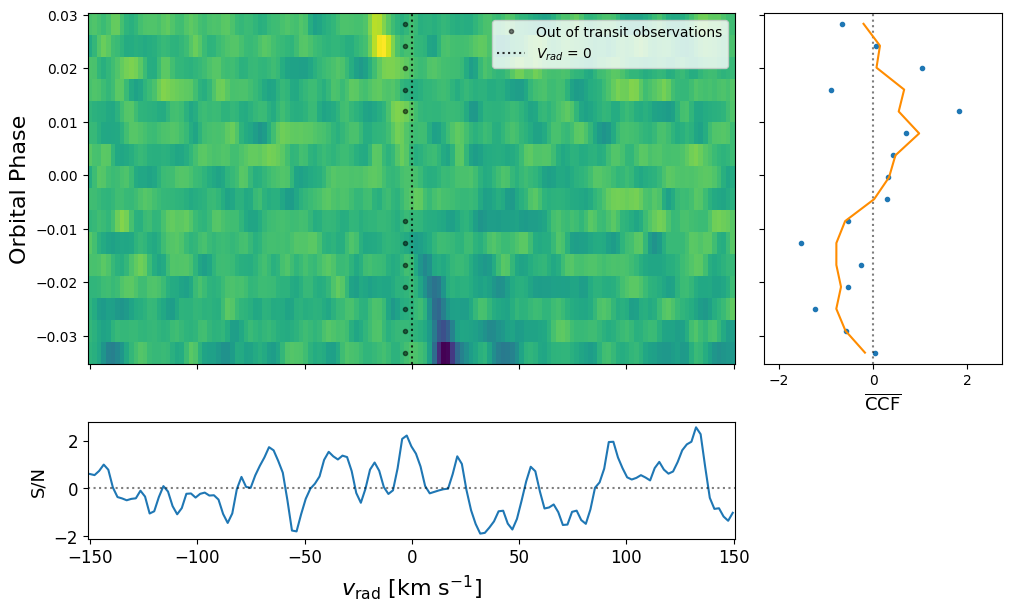



2021-10-24
Max value at 0 nPC = -0.4320724310350247 at 6.219994105902935 km/s
Max value at 0 nPC = -0.43044450518235794 at 6.219994147307437 km/s
Max value at 0 nPC = -0.43044450518235794 at 6.219994147307437 km/s


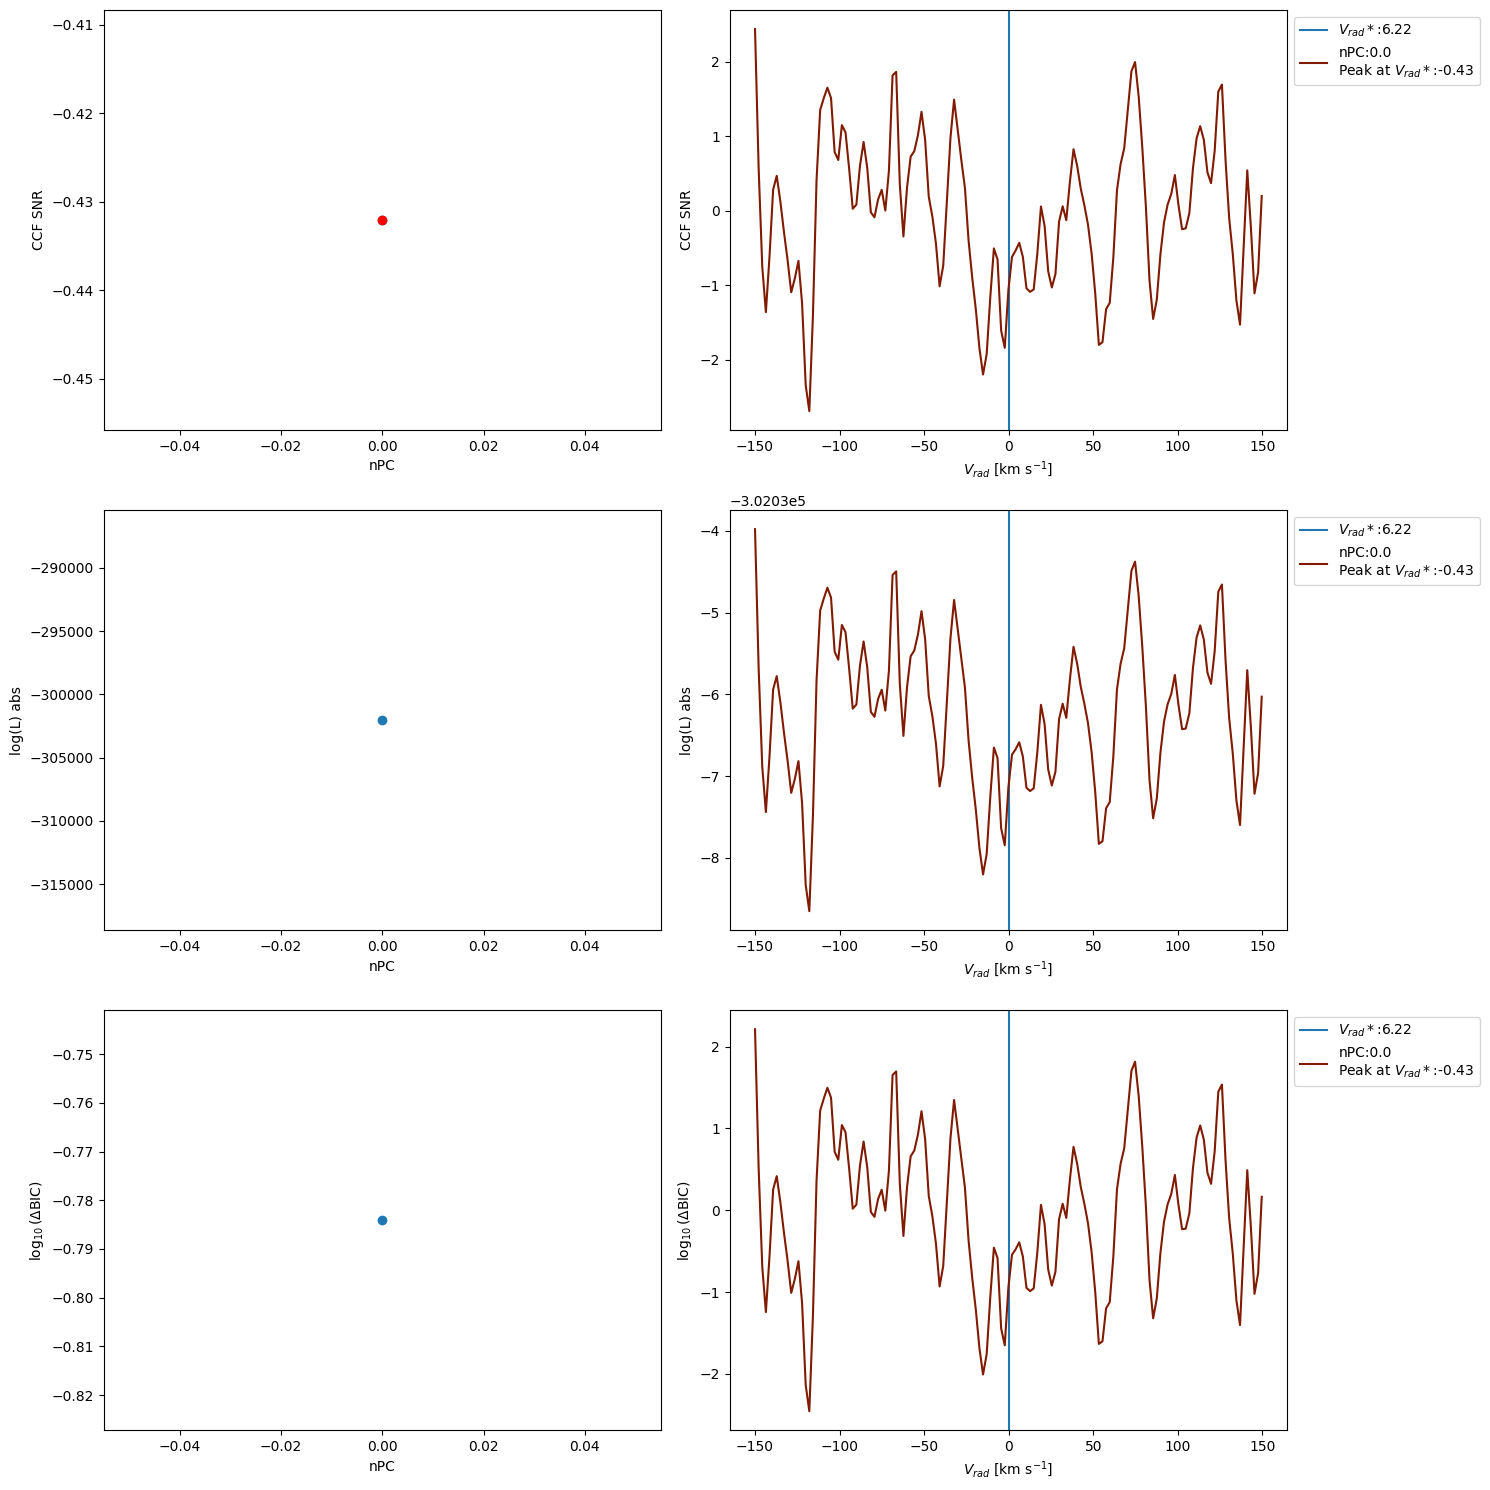

CCF SNR peak at Vrad*: [-0.43207243]
log(L) abs peak at Vrad*: [-302036.58571617]
log_10(ΔBIC) peak at Vrad*: [-0.78409857]
Saved file to :  /scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/2021-10-24/Figures/fig_CCF_2Dsequence_0-pc_mask_wings97_data_trs_2021-10-24_ccf_logl_seq_TRAPPIST-1b_H2O_v03_pc0.pdf
In-transit t-val = 0.13 / p-val 8.98e-01 / sig = -1.27
Out-of-transit t-val = -4.01 / p-val 2.93e-04 / sig = 3.44


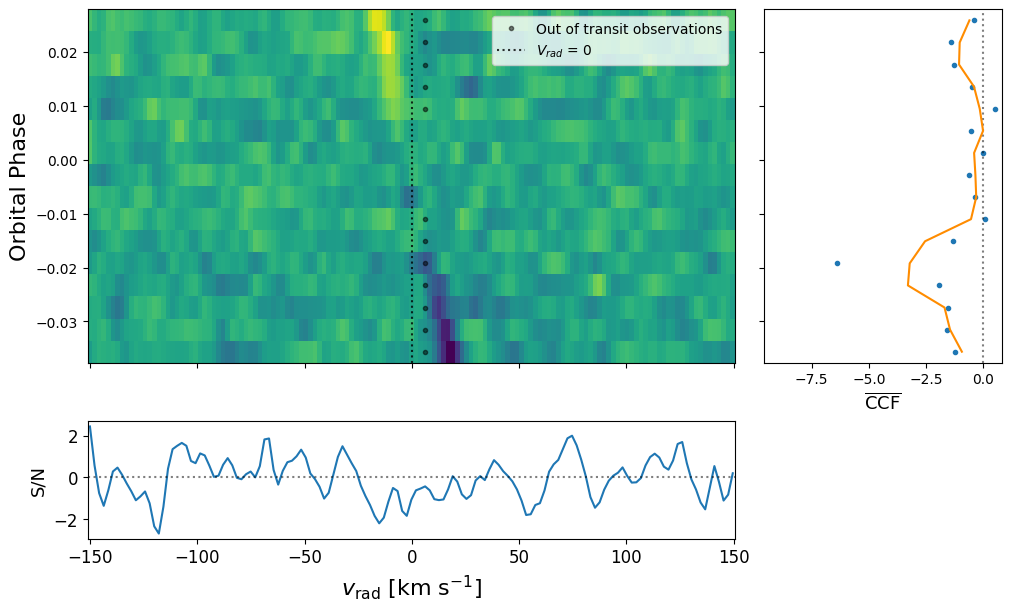



2021-10-27
Max value at 0 nPC = 2.2023279320319165 at -4.019381525732278 km/s
Max value at 0 nPC = 2.23040570427529 at -4.014707320483783 km/s
Max value at 0 nPC = 2.23040570427529 at -4.014707320483783 km/s


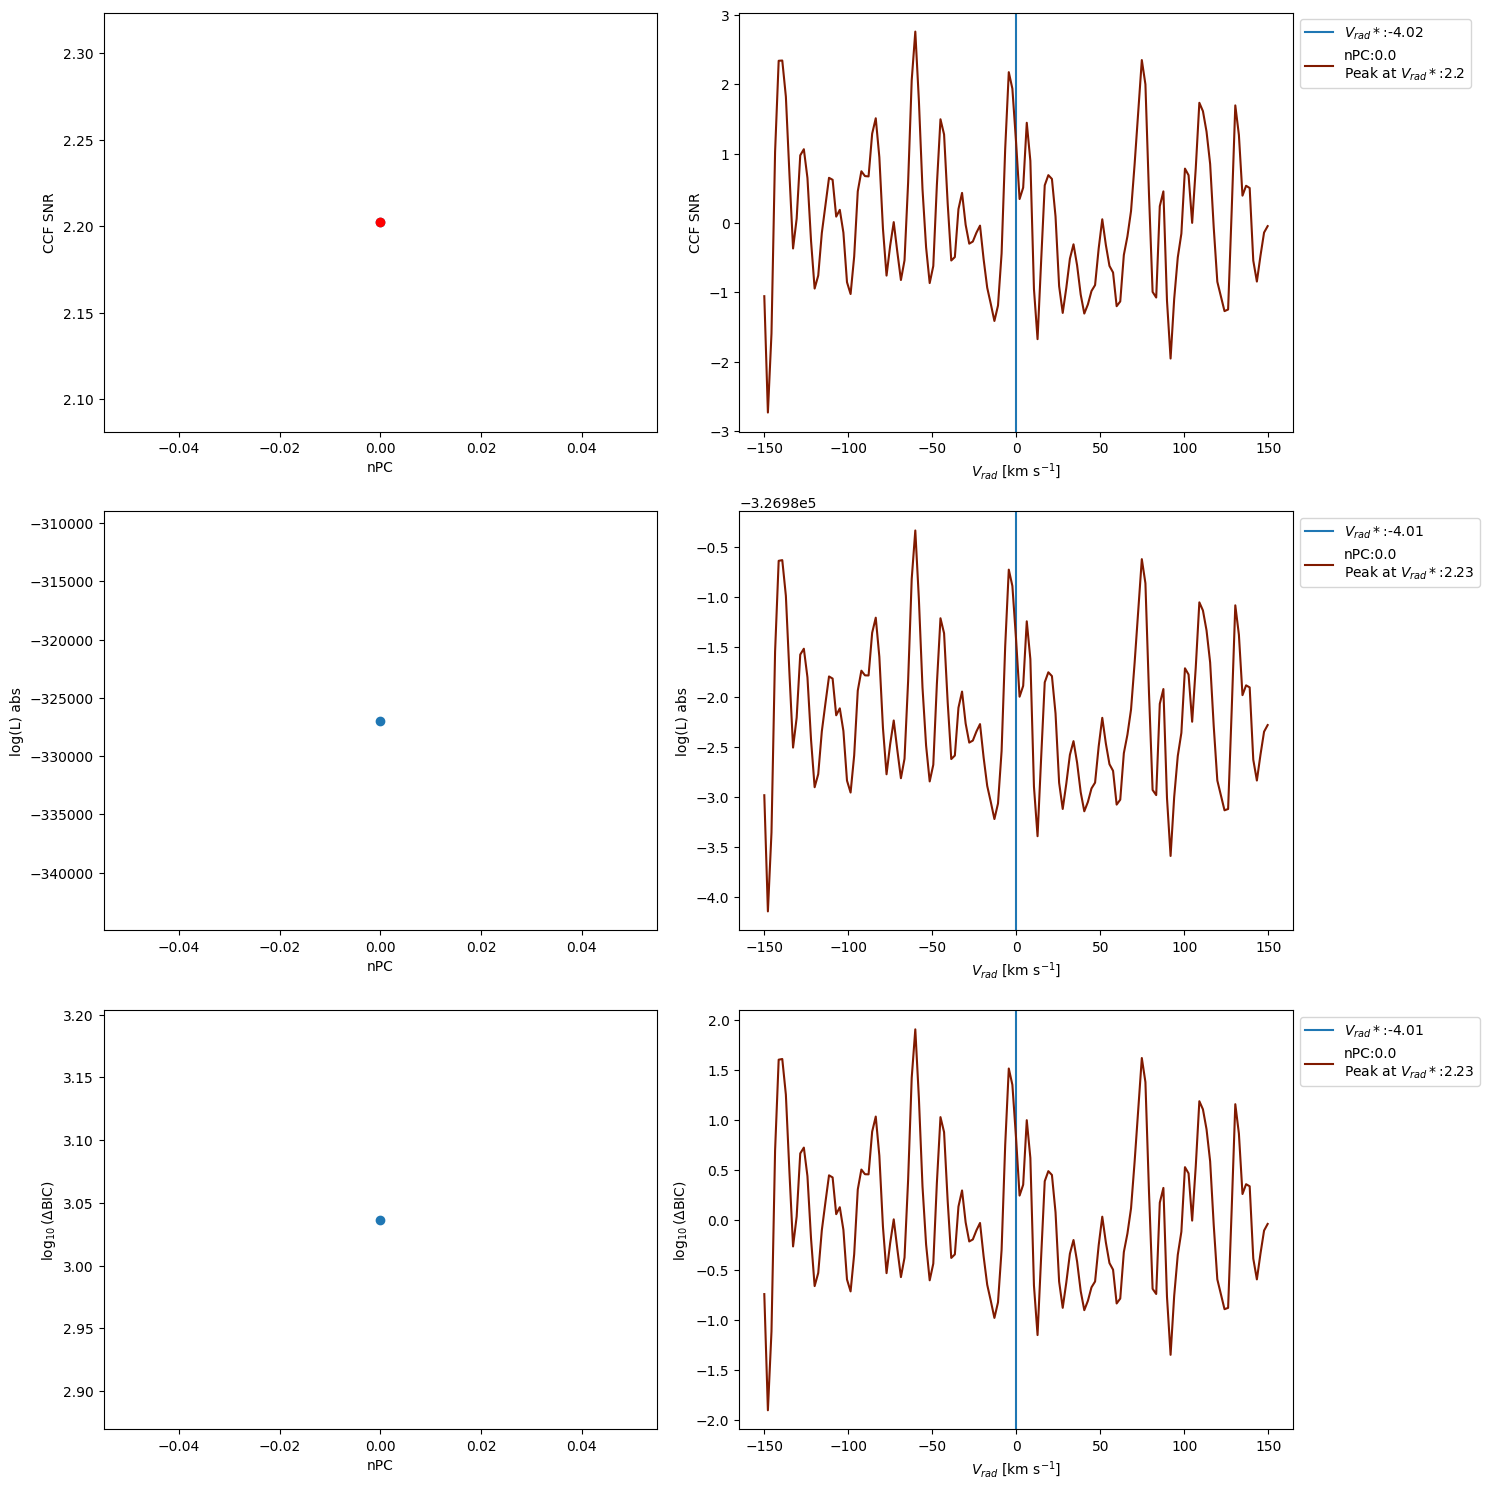

CCF SNR peak at Vrad*: [2.20232793]
log(L) abs peak at Vrad*: [-326980.72427597]
log_10(ΔBIC) peak at Vrad*: [3.03645867]
Saved file to :  /scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/2021-10-27/Figures/fig_CCF_2Dsequence_0-pc_mask_wings97_data_trs_2021-10-27_ccf_logl_seq_TRAPPIST-1b_H2O_v03_pc0.pdf
In-transit t-val = 2.27 / p-val 4.38e-02 / sig = 1.71
Out-of-transit t-val = 1.50 / p-val 1.40e-01 / sig = 1.08


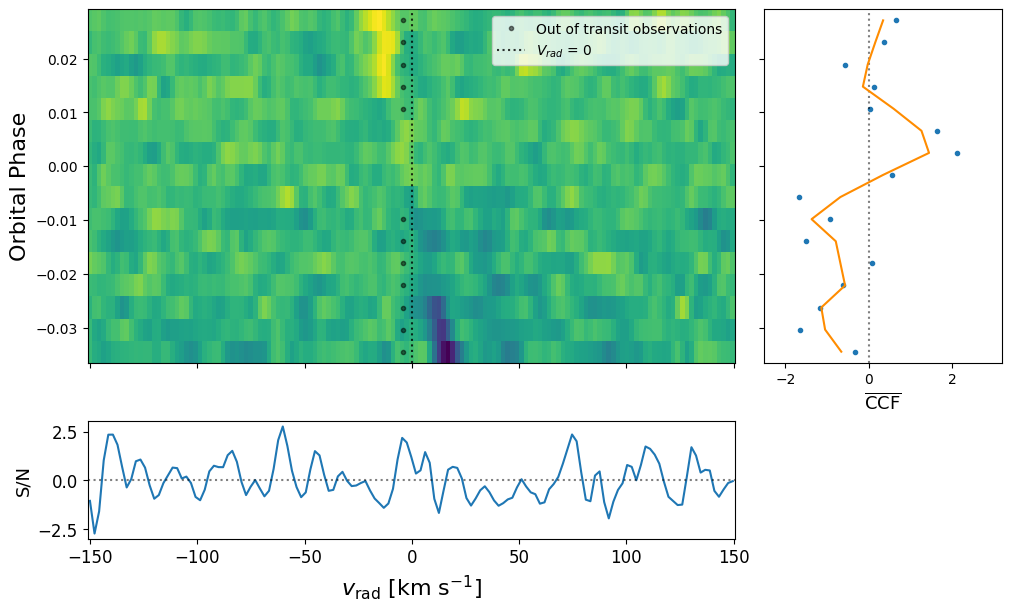

In [6]:
# CHOOSE NIGHTS TO PLOT
visits_plot = [
            "2019-06-14",
            "2019-09-25",
            "2020-05-31",
            "2020-08-04",
            "2020-09-08",
            "2020-09-20",
            "2020-09-26",
            "2020-09-29",
            "2021-10-21",
            "2021-10-24",
            "2021-10-27"
               ]


# OPTIONAL: plot a specific number of PCs
n_pc_plot = 0  # int or None -- if None, shows best nPC values


# INDICES OF ORDERS THAT SHOULD NOT BE USED IN THE PLOTS
orders_to_delete = [[0,1,2,3,4], [10,11,12,13,14], [23,24,25], [37,38,39], [46,47,48]]


#-------------------------------------------------------------------------------------#


order_indices = np.arange(obs.nord)  # array of orders

# Remove each element of orders_to_delete from array of orders
for elem in orders_to_delete:
    order_indices = np.setdiff1d(order_indices, elem)


for visit_name in visits_plot:

    # Directory where the correlations are
    if output_in_scratch:
        output_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{visit_name}')
    else:
        output_dir = Path(f'/home/mathisb/Github/HRS_correlations/{instrument}/{pl_name_fname}/{visit_name}')

    # Create figures directory if it does not exist
    fig_dir = output_dir / "Figures"
    fig_dir.mkdir(parents=True, exist_ok=True)

    
    print(f"\033[1m{visit_name}\033[0m")


    if n_pc_plot is None:  # if nPC has not been specified

        # Plot all ccf and logl as a function of nPC
        ccf_maps_in = np.concatenate([all_ccf_map[(visit_name, n)] for n in nPC_list], axis=-2)
        logl_maps_in = np.concatenate([all_logl_map[(visit_name, n)] for n in nPC_list], axis=-2)
        obs = all_obs[(visit_name, nPC_list[0])]


        id_pc0 = 0  # don't change
        n_pc_str = '-'.join(str(i) for i in nPC_list)
        fig_name = f'sequence_{n_pc_str}-pc_mask_wings97_data_trs_{visit_name}_ccf_logl_seq_{model_name}'


        ccf_obj, logl_obj = cc.plot_ccflogl(obs, ccf_maps_in, logl_maps_in, corrRV0, Kp_array, nPC_list, orders=order_indices,
                                            id_pc0=id_pc0, cmap="viridis", path_fig=str(fig_dir) + "/", fig_name=fig_name)

    else:
        
        fig_name = f'sequence_{n_pc_plot}-pc_mask_wings97_data_trs_{visit_name}_ccf_logl_seq_{model_name}'

        
        args = [all_something[(visit_name, n_pc_plot)] for all_something in [all_obs, all_ccf_map, all_logl_map]]
        ccf_obj, logl_obj = cc.plot_ccflogl(*args, corrRV0, Kp_array, [n_pc_plot], orders=order_indices,
                                            cmap="viridis", path_fig=str(fig_dir) + "/", fig_name=fig_name)

    
    plt.show()
    print("\n")
    

## Kp/Vrad plots

**Methods:**
- T-test map + distributions of cross-correlation values
- Box method
- Sigma-clipping

**Optional: plot all orders**

2020-09-20 | nPC=0


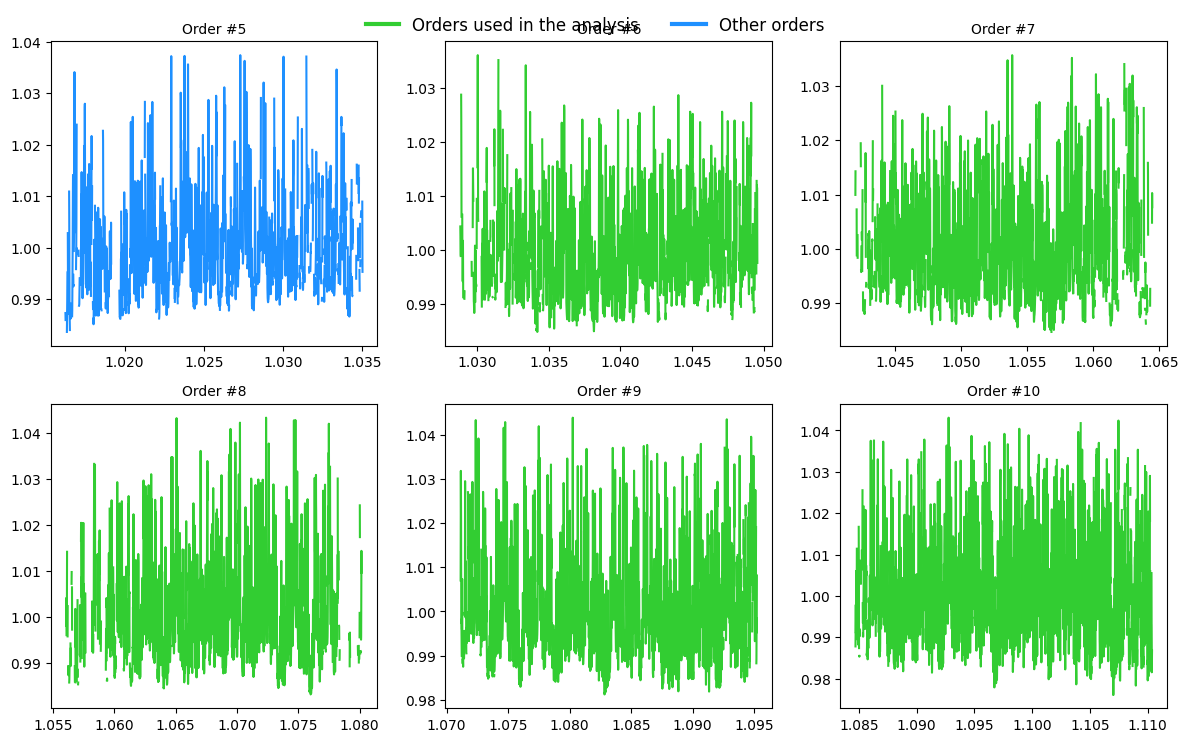

2020-09-20 | nPC=1


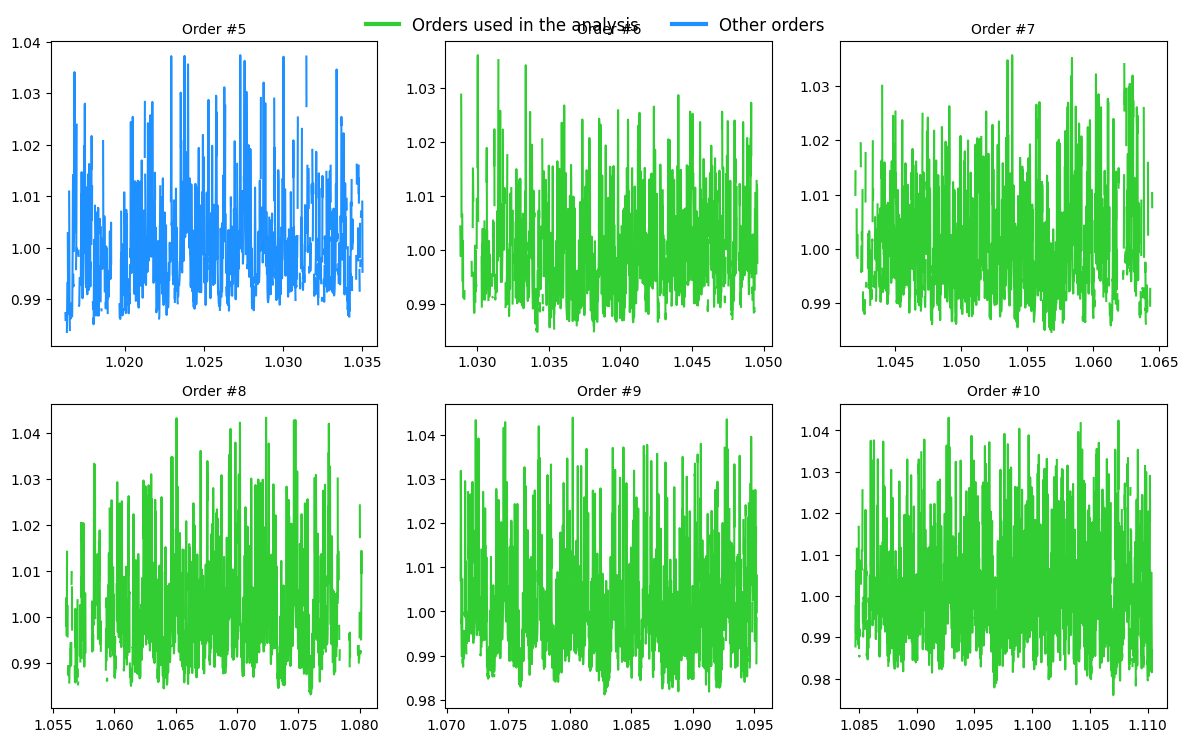

In [7]:
# CHOOSE METHOD
methods = [
        # 'ttest',
        # 'box',
        # 'clip'
          ]

# Choose Vrad (x-axis) Kp (y-axis) values for the plot
rv_grid = corrRV0
kp_grid = np.linspace(-80, 80, 161)

# Set Vrad and Kp limits for the box in the box method
box_Vrad = (50, 150)
box_Kp = (-60, -35)

# Set sigma limit and max number of iterations for the sigma-clipping method
clip_sigma = 2
clip_iter = 9


# PLOT THE CORRELATION MAP FOR EACH ORDER
plot_all_orders = False


# PLOT EACH ORDER OF THE MODEL
plot_model_orders = True
plot_these_orders = [4,5,6,7,8,9]  # 'all' or an arrat of specific orders
save_in_pdf = False  # save this plot in a pdf


#----------------------------------------------------------------#


for visit_name in visits_plot:
    
    # Build the list of (npc, obs) to plot for this night
    if n_pc_plot is not None:  # plot a single reduction
        combos = [(n_pc_plot, all_obs[(visit_name, n_pc_plot)])]
        
    else:  # plot all reductions
        combos = [(npc, obs)
                  for (visit, npc), obs in all_obs.items()
                  if visit == visit_name]

    
    # Loop once over whatever we decided to plot
    for npc, obs in combos:
        print(f"\033[1m{visit_name} | nPC={npc}\033[0m")


        # Get the right ccf object
        ccf_obj = Correlations(all_ccf_map[(visit_name, npc)], kind="logl", rv_grid=corrRV0, n_pcas=npc, kp_array=Kp_array)
        ccf_obj.calc_ccf2d(obs, ccf=None, kind='logl_corr', id_pc=None, remove_mean=False, index=None, orders=order_indices)
        ccf_obj.calc_logl(obs, orders=order_indices, index=None, N=None, nolog=False, icorr=obs.iIn, std_robust=True)
        
        
        if 'ttest' in methods:
            ccf_obj.ttest_map(obs, kind='logl', vrp=np.zeros_like(obs.vrp), orders=order_indices, 
                          kp0=0, RV_limit=corr_xlim, kp_step=5, rv_step=2, RV=None, speed_limit=3,
                              icorr=obs.iIn, equal_var=False)
        
        if 'box' in methods:
            pf.calculate_KpVsys_map(obs, ccf_obj, method='box', rv_grid=rv_grid, kp_grid=kp_grid,
                        box_Vrad=box_Vrad, box_Kp=box_Kp)
        
        if 'clip' in methods:
            pf.calculate_KpVsys_map(obs, ccf_obj, method='clip', rv_grid=rv_grid, kp_grid=kp_grid,
                        clip_sigma=clip_sigma, clip_iter=clip_iter)

        if plot_all_orders:
            pf.plot_all_orders_correl(corrRV0, ccf_obj.data.squeeze(), obs, icorr=None, logl=False, sharey=True,
                              vrp=np.zeros_like(obs.vrp), RV_sys=0.0, vmin=None, vmax=None, vline=None,
                              hline=2, kind='snr', return_snr=False, orders=order_indices)

        if plot_model_orders:
            pdfname = fig_dir / f"model_plot_orderbyorder_{visit_name}_{npc}-pc_maskwings97_{model_name}.pdf"
            pf.plot_model_orders(obs, wave_mod, model_spec, order_indices, plot_these_orders=plot_these_orders,
                                 save_in_pdf=save_in_pdf, pdfname=pdfname)


# Combined

## Combined setup

In [15]:
# REDUCTION DETAILS
nPC = 1  # nPC to use

coeffs = [0.02703969,  1.10037972, -0.96372403,  0.28750393]  # limb darkening coefficients
ld_model = 'nonlinear'  # limb darkening model

# Where are the reductions
reduc_in_scratch = False  # in the scratch directory (True) or in the home directory (False)


# CORRELATION DETAILS
kind_trans = 'transmission'  # emission or transmission

# Define cross-correlation axes
step_RV_inj = 2.14  # 2 times the resolution of SPIRou in km/s
corr_xlim = 150  # correlation will be done with Vrad values in [-corr_xlim, corr_xlim]

# Where to find the correlations
corr_in_scratch = True  # in the scratch directory (True) or in the home directory (False)


# NIGHTS TO COMBINE
file_arr = np.array([
                    # ['1', '2019-06-14', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2019-06-14.npz'],
                    ['2', '2019-09-25', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2019-09-25.npz'],
                    # ['3', '2020-05-31', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-05-31.npz'],
                    # ['4', '2020-08-04', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-08-04.npz'],
                    # ['5', '2020-09-08', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-08.npz'],
                    # ['6', '2020-09-20', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-20.npz'],
                    # ['7', '2020-09-26', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-26.npz'],
                    # ['8', '2020-09-29', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2020-09-29.npz'],
                    # ['9', '2021-10-21', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2021-10-21.npz'],
                    ['10', '2021-10-24', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2021-10-24.npz'],
                    # ['11', '2021-10-27', 'v001', f'sequence_{nPC}-pc_mask_wings97_data_trs_2021-10-27.npz'],
                    ])


## Run the combined correlation

In [16]:
pl_obs.log.setLevel("WARNING")  # do not print entire log in this cell


# Correlation setup
corrRV0 = np.arange(-corr_xlim, corr_xlim, step_RV_inj)  # x axis (Vrad)
combined_ccf = []
combined_logl = []
combined_obs = []
visit_dict = dict()
all_visits_str = ""


for reduc_idx, reduc in enumerate(file_arr):
    
    visit_nb = reduc[0]
    visit = reduc[1]
    version = reduc[2]
    fname = reduc[3]

    
    print("Loading", visit, "correlation...")

    
    # Directory where the reductions are
    if reduc_in_scratch:
        base_dir = Path(os.environ['SCRATCH'])
    else:
        base_dir = Path.home() / "Github"
    
    reduc_dir = base_dir / Path(f'HRS_reductions/{instrument}/{pl_name_fname}/{visit}/{version}')


    # Directory where the correlations are
    if corr_in_scratch:
        corr_dir = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/{visit}')
    else:
        corr_dir = Path(f'/home/mathisb/Github/HRS_correlations/{instrument}/{pl_name_fname}/{visit}')

    # Create figures directory if it does not exist
    fig_dir = corr_dir / "Figures"
    fig_dir.mkdir(parents=True, exist_ok=True)


    # Redefine planet (since mid-tr time changes for each visit)
    mid_tr = mid_tr_dict[visit]

    pl_kwargs = {'M_star': M_star, 
                 'R_star': R_star,
                 'ap': ap,
                 'R_pl': R_pl,
                 'mid_tr': mid_tr,
                 'excent': e,
                 'w': w}

    planet_obj = Planet(pl_name, **pl_kwargs)
    obs = pl_obs.load_single_sequences(fname, pl_name, path=reduc_dir, load_all=False, filename_end='', plot=False, planet=planet_obj)

    
    out_filename = f'{Path(fname).stem}_ccf_logl_seq_{model_name}'

    
    try:
        # Check if already generated
        saved_values = np.load(corr_dir / Path(out_filename).with_suffix('.npz'))
        ccf_map = saved_values['corr']
        logl_map = saved_values['logl']

        
    except FileNotFoundError:
        # Generate 1d correlations  --  ccf_map shape: (n_exposures, n_order, n_Kp, n_vsys, n_pc, n_model)
        ccf_map, logl_map = corr.calc_logl_injred(obs,'seq', planet_obj, Kp_array, corrRV0, [nPC], wave_mod, model_spec, kind_trans)
        corr.save_logl_seq(corr_dir / Path(out_filename), ccf_map, logl_map, wave_mod, model_spec, nPC, Kp_array, corrRV0, kind_trans)
    

    all_visits_str += visit_nb + "-"
    
    visit_dict[str(reduc_idx + 1)] = obs
    combined_obs.append(obs)
    combined_ccf.append(ccf_map)
    combined_logl.append(logl_map)


transit_tags = [np.arange(obs.n_spec) for obs in visit_dict.values()]
all_visits = pl_obs.gen_merge_obs_sequence(obs, visit_dict, np.arange(1, len(file_arr) + 1), None, coeffs, ld_model, kind_trans, light=True)
all_visits.dt = np.concatenate([vst.dt for vst in visit_dict.values()])  # exposition times
all_vists_str = all_visits_str[:-1]
visit_dict[all_visits_str.replace("-", "")] = all_visits


pl_obs.log.setLevel("INFO")  # go back to normal log printing

Loading 2019-09-25 correlation...
Loading 2021-10-24 correlation...


## Plot the combined correlation

Max value at 1 nPC = 1.361548223404891 at 6.2199965242117266 km/s
Max value at 1 nPC = 1.368665701054166 at 6.2199965242117266 km/s
Max value at 1 nPC = 1.368665701054166 at 6.2199965242117266 km/s


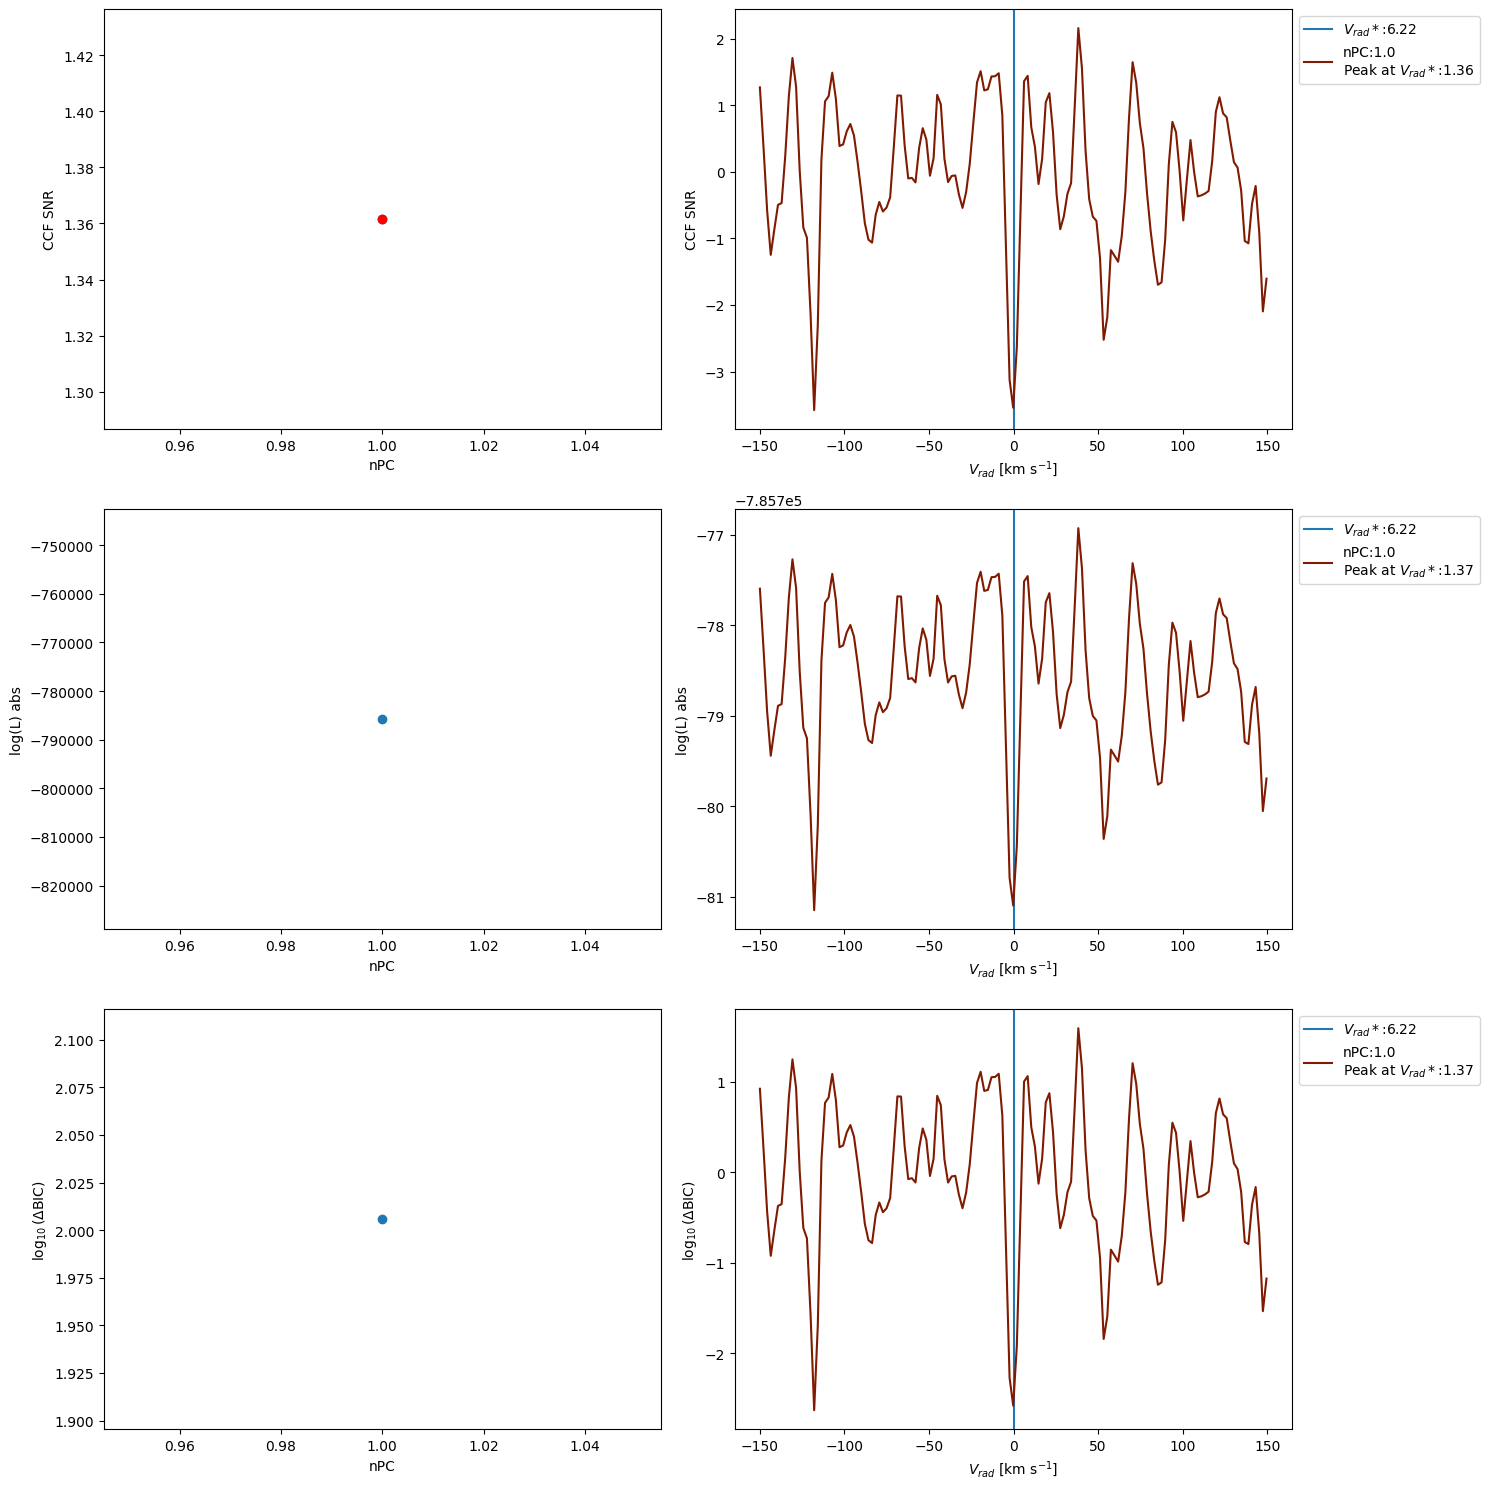

CCF SNR peak at Vrad*: [1.36154822]
log(L) abs peak at Vrad*: [-785777.51754525]
log_10(ΔBIC) peak at Vrad*: [2.0057249]
Saved file to :  /scratch/mathisb/HRS_correlations/SPIRou_with_persi/TRAPPIST-1b/Combined/Figures/fig_CCF_2Dcombined_corr_nights2-10-_pc1-1_mask_wings97-97_TRAPPIST-1b_H2O_v03_pc1.pdf
In-transit t-val = 1.34 / p-val 1.91e-01 / sig = 0.87
Out-of-transit t-val = -4.11 / p-val 1.11e-04 / sig = 3.69
T-val : Max value = 1.8 // Max position = 7.7
Histogram for Kp = 83.08 and RV = 6.22


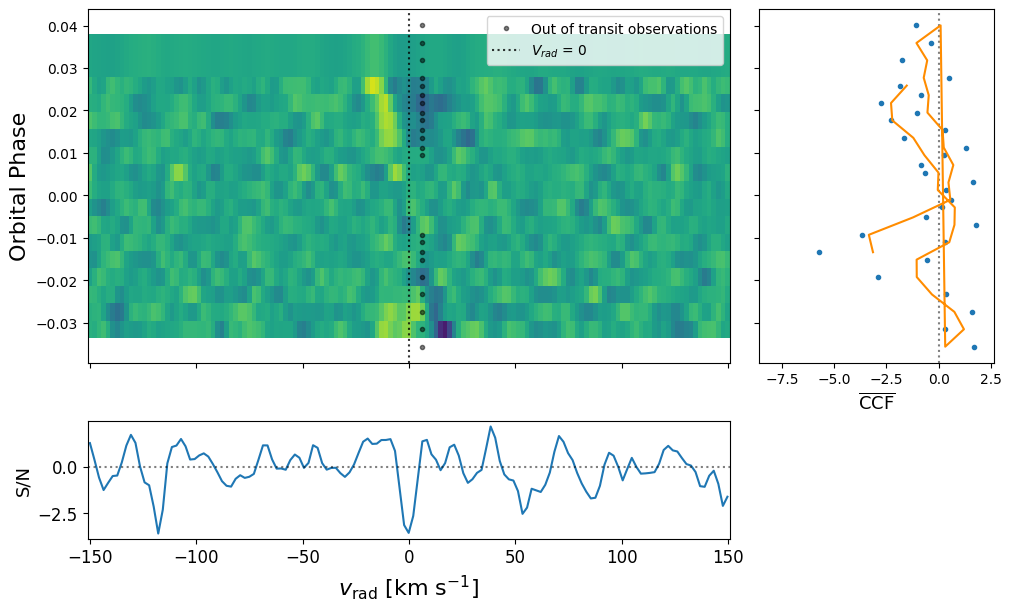

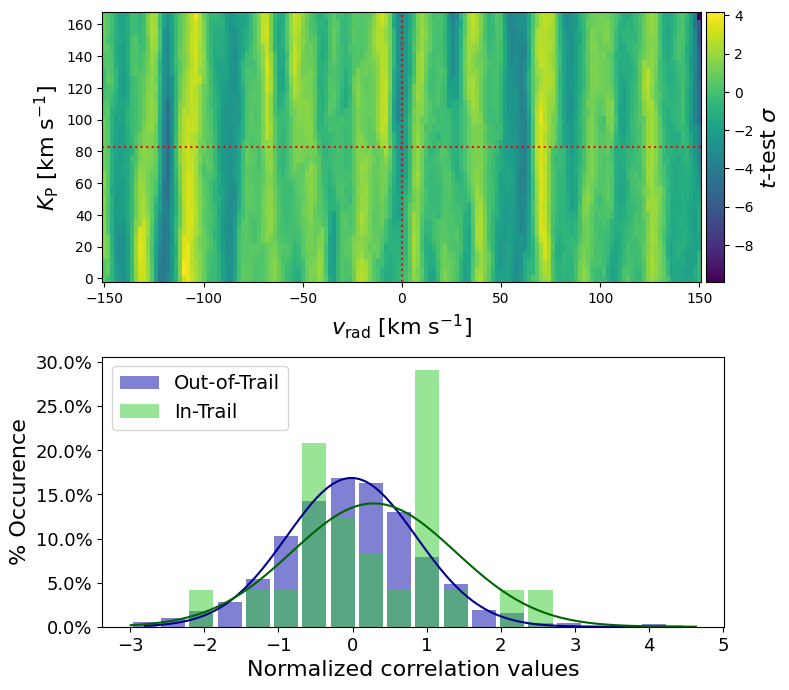

<Figure size 640x480 with 0 Axes>

In [18]:
# INDICES OF ORDERS THAT SHOULD NOT BE USED IN THE PLOTS
orders_to_delete = [[0,1,2,3,4], [10,11,12,13,14], [23,24,25], [37,38,39], [46,47,48]]


# BOX AND SIGMA-CLIPPING METHODS

# Choose Vrad (x-axis) Kp (y-axis) values
rv_grid = corrRV0
kp_grid = np.linspace(-obs.Kp.value, obs.Kp.value, 161)

# Set Vrad and Kp limits for the box in the box method
box_Vrad = (50, 150)
box_Kp = (-60, -35)

# Set sigma limit and max number of iterations for the sigma-clipping method
clip_sigma = 2
clip_iter = 9


#-------------------------------------------------------------------------------------#


# Where to output the combined correlations
output_dir_comb = Path(os.environ['SCRATCH']) / Path(f'HRS_correlations/{instrument}/{pl_name_fname}/Combined/')

# Figures directory
fig_dir_comb = str(output_dir_comb) + "/Figures/"


# Create filename for combined correlation file
args_filename = []
        
for i in range(len(file_arr)):
    args_filename.append((str(visit_dict[str(i + 1)].params[5]), str(int(visit_dict[str(i + 1)].params[1] * 100))))

args_filename = ['-'.join(values) for values in zip(*args_filename)]
filename = 'combined_corr_nights{}'.format(all_visits_str) + '_pc{}_mask_wings{}_'.format(*args_filename) + f"{model_name}"


idx_orders = np.arange(obs.nord)  # array of orders

# Remove each element of orders_to_delete from array of orders
for elem in orders_to_delete:
    idx_orders = np.setdiff1d(idx_orders, elem)


# Create the CCF (combined) object
ccf_map = np.concatenate(combined_ccf)
logl_map = np.concatenate(combined_logl)

ccf_obj_comb, logl_obj_comb = cc.plot_ccflogl(all_visits, 
                                    ccf_map,
                                    logl_map,
                                    corrRV0, np.array([obs.Kp.value]),
                                    [nPC], orders=idx_orders,
                                    path_fig=fig_dir_comb,
                                    fig_name=filename,
                                    cmap='viridis'
                                   )


# Plot the CCF
ccf_obj_comb.ttest_map(all_visits, kind='logl', vrp=np.zeros_like(all_visits.vrp), orders=idx_orders, kp0=0, cmap='viridis',
                  RV_limit=150, kp_step=5, rv_step=2, RV=None, speed_limit=3, icorr=all_visits.iIn, equal_var=False)


# Save combined correlation
pl_obs.save_sequences(filename, visit_dict, [int(all_visits_str.replace("-", ""))], path=output_dir_comb, print_out=False)


In [ ]:
# Plot box and sigma-clipping methods
pf.calculate_KpVsys_map(all_visits, ccf_obj_comb, method='box', rv_grid=rv_grid, kp_grid=kp_grid,
                        box_Vrad=box_Vrad, box_Kp=box_Kp)
pf.calculate_KpVsys_map(all_visits, ccf_obj_comb, method='clip', rv_grid=rv_grid, kp_grid=kp_grid,
                        clip_sigma=clip_sigma, clip_iter=clip_iter)

## Sensitivity vs number of transits (optional)

In [ ]:
# This was done one group of transits at a time (first running the combined corr. with 1 transit, then 2, then 3...).
# If done again, this would need to be adapted in some way and added into the code above, or the code above could be
# copied here and run just once to get the final plot.


# # Create lists of cross-correlation values
# nb_transits_list = []
# std_dev_list = []
# signal_str_list = []


# # GET CCF VALUES FOR EACH Vrad (to do in the code above)
# ccf_vals = ccf_obj.logl.squeeze()
# nb_transits_list.append(len(file_arr))


# # GET STD DEVIATION OF CCF OUTSIDE OF TRAIL
# # Get ccf values outside trail (v_rad = -150 to -100 and 100 to 150)
# ccf_outside_trail = np.concatenate((ccf_vals[:24], ccf_vals[117:]), axis=0)

# # Calculate std deviation
# ccf_std_dev = np.std(ccf_outside_trail)
# print(f"Standard deviation with {len(file_arr)} transits is", ccf_std_dev)

# std_dev_list.append(ccf_std_dev)


# # GET SIGNAL STRENGTH AT Vrad = 0
# # Get ccf values around Vrad = 0
# ccf_at_zero = ccf_vals[68:73]

# # Calculate mean signal
# ccf_mean = np.mean(ccf_at_zero)
# print(f"Mean ccf signal value with {len(file_arr)} transits is", ccf_mean)

# signal_str_list.append(ccf_mean)


# # Check that everything makes sense
# print(np.shape(ccf_vals))
# print(np.shape(ccf_outside_trail))
# print(np.shape(ccf_at_zero))

# plt.figure(figsize=(4.3,4))
# plt.plot(corrRV0, ccf_vals)  # should look like the CCF SNR plot above
# plt.show()

In [ ]:
# # PLOT NOISE AND SIGNAL VS NB OF TRANSITS
# std_dev_arr = np.array(std_dev_list) * 10e3
# signal_str_arr = np.array(signal_str_list) * 10e3

# plt.scatter(nb_transits_list, std_dev_arr, color="mediumblue", s=60, label="Standard deviation outside trail")
# plt.scatter(nb_transits_list, signal_str_arr, color="gold", s=60, label="Signal strength")

# plt.xlabel("Number of nights")
# plt.ylabel("Cross-correlation value [x$10^{3}$]")
# plt.legend()
# plt.show()